### Analisis dan Klasifikasi Gangguan Jaringan pada Gedung Kantor Dinas Komunikasi dan Informatika Kota Tangerang Selatan

- Hybrid Model Menggunakan K-Means Cluster & Klasifikasi
- Model ini Memprediksi Gangguan Jaringan Berdasarkan Label Severity Score

<img src="img/bluebanner.png" width="900">

### Studi Kasus Diskominfo Kota Tangerang Selatan dengan Pendekatan CRISP-DM

RAAFA SYAHIDUL HAQ IRSI - 221011402562

Judul Penelitian :`IMPLEMENTASI METODE ALGORITMA RANDOM FOREST DAN NAIVE BAYES DALAM MEMPREDIKSI GANGGUAN JARINGAN BERBASIS WEBSITE MENGGUNAKAN FLASK PYTHON PADA DISKOMINFO TANGERANG SELATAN`

# Import Library

In [174]:
import os
import json
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    learning_curve,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    silhouette_score
)

import joblib

warnings.filterwarnings("ignore")

sns.set(style="darkgrid")

print("Library berhasil dimuat")

Library berhasil dimuat


### SETUP FOLDER

In [175]:
BASE_DIR = os.getcwd()

STATIC_DIR = os.path.join(BASE_DIR, "static")
MODELS_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(STATIC_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

def save_plot(filename):
    plt.tight_layout()
    plt.savefig(
        os.path.join(STATIC_DIR, filename),
        dpi=150,
        bbox_inches="tight"
    )
    plt.close()

# Bussiness Understanding

Gangguan jaringan merupakan salah satu permasalahan yang dapat memengaruhi kualitas layanan teknologi informasi pada lingkungan kantor gedung pemerintahan. Keterlambatan dalam mendeteksi gangguan dapat berpotensi menyebabkan penurunan kinerja sistem maupun pegawai, terganggunya akses informasi dan sumberdaya.

Penelitian ini bertujuan membangun model klasifikasi berbasis Machine Learning untuk memprediksi kondisi jaringan ke dalam kategori normal dan gangguan berdasarkan data hasil capturing tim teknisi jaringan. Model yang digunakan adalah `Random Forest` dan `Naive Bayes` sehingga dapat dibandingkan performanya dalam mengidentifikasi pola gangguan jaringan.

Hasil penelitian diharapkan dapat membantu tim teknisi jaringan dalam proses monitoring jaringan secara lebih efektif, konsisten, dan berbasis data sehingga hasil data pada model ini dapat mendukung pengambilan keputusan teknis pada lingkungan Diskominfo Kota Tangerang Selatan.

### Load Data

In [176]:
data_path = os.path.join(BASE_DIR, "clear_data_kominfo.csv")

df_raw = pd.read_csv(data_path, sep=';')

print("Data berhasil dibaca")
print("Ukuran dataset:", df_raw.shape)

display(df_raw.head())

print("\nInfo dataset:")
df_raw.info()

Data berhasil dibaca
Ukuran dataset: (5819, 29)


,protocol,start_time,end_time,duration_seconds,total_packets,forward_packets,backward_packets,is_bidirectional,forward_backward_ratio,total_bytes,...,avg_packet_size,avg_inter_arrival_ms,min_inter_arrival_ms,max_inter_arrival_ms,tcp_flags,syn_count,fin_count,rst_count,ack_count,connection_state
0,UDP,2026-04-29 15:45:27.933591,2026-04-29 15:46:10.233500,42.299.909,21209,2249,18960,True,0.11861814345991561,24059374,...,11.343.945.494.837.000,19.945.260.750.660.100,-0.091,25.641.489,NaN,0,0,0,0,Unknown
1,TCP,2026-04-29 14:56:37.159573,2026-04-29 14:57:10.726682,33.567.109,6956,4481,2475,True,18.105.050.505.050.500,6374307,...,9.163.753.594.019.550,4.826.327.677.929.540,-0.004,14.138.509.999.999.900,"A,FA,PA,RA,S,SA",1,2,1,6955,Closed
2,TCP,2026-04-29 15:50:09.578485,2026-04-29 15:53:41.758948,212.180.463,3837,552,3285,True,0.1680365296803653,4991415,...,13.008.639.562.157.900,55.312.946.558.915.500,0.0,61.625.391,"A,FA,PA,S,SA",1,2,0,3836,Closed
3,UDP,2026-04-29 15:30:02.366193,2026-04-29 15:30:14.934230,12.568.037,3977,525,3452,True,0.15208574739281575,4308051,...,108.324.138.798.089,3.160.975.100.603.620,-0.04,4.819.866,NaN,0,0,0,0,Unknown
4,UDP,2026-04-29 15:30:02.391197,2026-04-29 15:30:10.197485,7.806.288,2598,346,2252,True,0.15364120781527532,2832963,...,10.904.399.538.106.200,300.588.679.245.283,-0.037,3.865.801,NaN,0,0,0,0,Unknown



Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 5819 entries, 0 to 5818
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   protocol                5819 non-null   str  
 1   start_time              5819 non-null   str  
 2   end_time                5819 non-null   str  
 3   duration_seconds        5819 non-null   str  
 4   total_packets           5819 non-null   int64
 5   forward_packets         5819 non-null   int64
 6   backward_packets        5819 non-null   int64
 7   is_bidirectional        5819 non-null   bool 
 8   forward_backward_ratio  5819 non-null   str  
 9   total_bytes             5819 non-null   int64
 10  forward_bytes           5819 non-null   int64
 11  backward_bytes          5819 non-null   int64
 12  total_payload_bytes     5819 non-null   int64
 13  forward_payload_bytes   5819 non-null   int64
 14  backward_payload_bytes  5819 non-null   int64
 15  packets_per_secon

# Data Understanding

Dataset yang digunakan merupakan data hasil capturing jaringan yang masih berada dalam kondisi mentah. Pada tahap awal ini dilakukan proses identifikasi struktur data untuk memahami karakteristik atribut yang tersedia sebelum masuk ke proses analisis lebih lanjut.

Tahap ini penting karena kualitas pemahaman terhadap data akan sangat mempengaruhi kualitas feature engineering maupun proses modeling yang dilakukan setelahnya.

Tahap Data Understanding dilakukan untuk memahami karakteristik data monitoring jaringan yang digunakan dalam penelitian. Pada tahap ini dilakukan proses identifikasi struktur data, jumlah observasi, tipe data, statistik deskriptif, serta kualitas data secara keseluruhan.

Parameter yang dianalisis berasal dari hasil capturing jaringan dan akan digunakan sebagai dasar pembentukan fitur Machine Learning untuk mendeteksi kondisi jaringan normal maupun gangguan.

### Shape Data

In [177]:
# Shape dataset
df_raw.shape

(5819, 29)

Jumlah observasi pada dataset menunjukkan bahwa data monitoring memiliki volume yang cukup untuk dilakukan proses pembelajaran model machine learning.

Banyaknya observasi akan membantu model dalam mempelajari pola performa jaringan secara lebih stabil.

In [178]:
# Statistik deskriptif
df_raw.describe(include="all")

,protocol,start_time,end_time,duration_seconds,total_packets,forward_packets,backward_packets,is_bidirectional,forward_backward_ratio,total_bytes,...,avg_packet_size,avg_inter_arrival_ms,min_inter_arrival_ms,max_inter_arrival_ms,tcp_flags,syn_count,fin_count,rst_count,ack_count,connection_state
count,5819,5819,5819,5819,5819.000000,5819.000000,5819.000000,5819,5819,5.819000e+03,...,5819,5819,5819,5819,693,5819.000000,5819.000000,5819.000000,5819.000000,5819
unique,5,5633,5536,2694,NaN,NaN,NaN,2,358,NaN,...,1334,2694,1648,2690,26,NaN,NaN,NaN,NaN,5
top,UDP,2026-04-29 15:18:41.442762,2026-04-29 14:56:26.449480,0.0,NaN,NaN,NaN,False,inf,NaN,...,594.0,0.0,0.0,0.0,"A,FA,PA,S,SA",NaN,NaN,NaN,NaN,Unknown
freq,4663,5,7,3097,NaN,NaN,NaN,4131,3780,NaN,...,2031,3097,4092,3097,352,NaN,NaN,NaN,NaN,5126
mean,NaN,NaN,NaN,NaN,34.162743,16.592714,17.570029,NaN,NaN,2.209458e+04,...,NaN,NaN,NaN,NaN,NaN,0.121155,0.227015,0.051383,12.062554,NaN
std,NaN,NaN,NaN,NaN,359.179921,146.544620,280.562158,NaN,NaN,3.611016e+05,...,NaN,NaN,NaN,NaN,NaN,0.375327,0.831148,0.306803,161.291873,NaN
min,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,4.200000e+01,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,1.880000e+02,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,5.940000e+02,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN
75%,NaN,NaN,NaN,NaN,7.000000,6.000000,1.000000,NaN,NaN,9.230000e+02,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN


Statistik deskriptif memberikan gambaran awal mengenai pola distribusi data, sebaran nilai, serta potensi adanya nilai ekstrem pada beberapa atribut jaringan.

Tahap ini membantu dalam memahami perilaku dasar data sebelum dilakukan pembersihan dan transformasi lebih lanjut.

### Cleaning Format Data

In [179]:
def clean_number(x):
    try:
        return float(str(x).replace(".", "").replace(",", "."))
    except:
        return np.nan

### Missing Values

In [180]:
# Missing value
missing_values = df_raw.isnull().sum()

missing_values

protocol                     0
start_time                   0
end_time                     0
duration_seconds             0
total_packets                0
forward_packets              0
backward_packets             0
is_bidirectional             0
forward_backward_ratio       0
total_bytes                  0
forward_bytes                0
backward_bytes               0
total_payload_bytes          0
forward_payload_bytes        0
backward_payload_bytes       0
packets_per_second           0
bytes_per_second             0
min_packet_size              0
max_packet_size              0
avg_packet_size              0
avg_inter_arrival_ms         0
min_inter_arrival_ms         0
max_inter_arrival_ms         0
tcp_flags                 5126
syn_count                    0
fin_count                    0
rst_count                    0
ack_count                    0
connection_state             0
dtype: int64

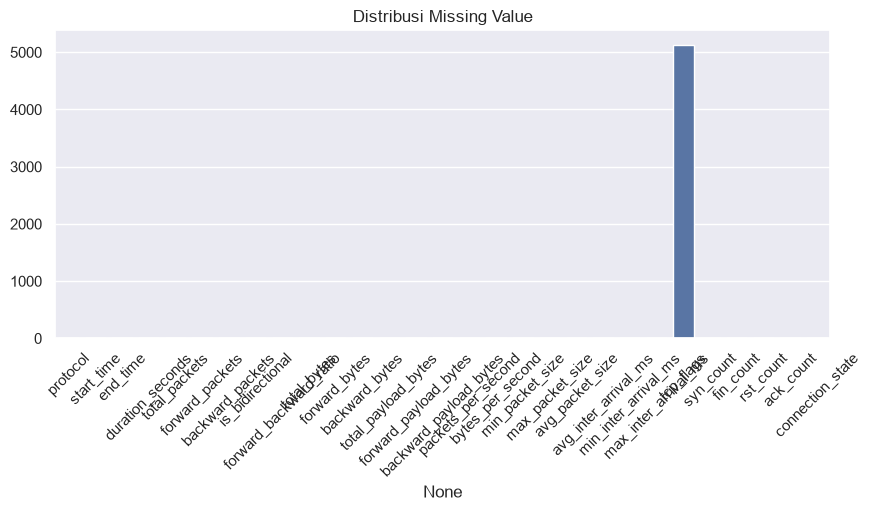

In [181]:
plt.figure(figsize=(10,4))

sns.barplot(
    x=missing_values.index,
    y=missing_values.values
)

plt.xticks(rotation=45)
plt.title("Distribusi Missing Value")

plt.savefig("static\missing_values.png")
plt.show()

Setelah dilihat ternyata data Missing Values Terbanyak dimiliki oleh feature yang bernama `tcp_flags`  namun feature tersebut tidak akan saya gunakan sebagai variabel prediksi karena tidak memiliki nilai yang relevan

### Menentukan Nilai Numerik ke Bilangan Desimal (Float)

In [182]:
numeric_cols = [
    "bytes_per_second",
    "avg_inter_arrival_ms",
    "forward_packets",
    "backward_packets",
    "total_packets",
    "duration_seconds"
]

df = df_raw.copy()

for col in numeric_cols:
    df[col] = df[col].apply(clean_number)

Pada tahap ini saya melakukan Mappping Feature karena feature feature ini sangat berpengaruh pada variabel yang akan dijadikan sumber utama paramter yang nantinya dapat di predict 

    `bytes_per_second`,
    `avg_inter_arrival_ms`,
    `forward_packets`,
    `backward_packets`,
    `total_packets`,
    `duration_seconds`

karena format numerik pada dataset masih belum konsisten. Beberapa nilai numerik masih tersimpan sebagai string sehingga tidak dapat langsung diproses oleh model machine learning.

Proses konversi dilakukan untuk memastikan seluruh atribut numerik dapat dianalisis secara matematis tanpa menyebabkan error pada tahap modeling.

### Transformasi Data Hasil Capturing Menjadi Parameter Jaringan

Data hasil capturing trafik jaringan dengan menggunakan `Wireshark` belum dapat digunakan secara langsung pada proses klasifikasi karena masih berupa atribut teknis tingkat rendah (low-level network attributes). Oleh karena itu dilakukan proses transformasi atribut menjadi parameter jaringan yang lebih representatif dan mudah diinterpretasikan, yaitu `bandwidth`, `latency`, `packet_loss`, dan `uptime`.

Keempat parameter tersebut digunakan sebagai variabel utama dalam proses perhitungan `Severity Score`, analisis clustering menggunakan `K-Means`, serta pembangunan model klasifikasi menggunakan algoritma `Random Forest` dan `Gaussian Naive Bayes`.


In [183]:
df_raw[[
    "bytes_per_second",
    "avg_inter_arrival_ms",
    "forward_packets",
    "backward_packets",
    "duration_seconds"
]].head()

,bytes_per_second,avg_inter_arrival_ms,forward_packets,backward_packets,duration_seconds
0,5.687.807.508.049.240,19.945.260.750.660.100,2249,18960,42.299.909
1,18.989.740.820.396.500,4.826.327.677.929.540,4481,2475,33.567.109
2,23.524.385.466.158.500,55.312.946.558.915.500,552,3285,212.180.463
3,3.427.783.511.458.470,3.160.975.100.603.620,525,3452,12.568.037
4,36.290.782.507.639.900,300.588.679.245.283,346,2252,7.806.288


Pada tahap ini dilakukan proses pemilihan atribut yang relevan dari dataset hasil proses capturing paket jaringan menggunakan aplikasi `Wireshark`. Data yang diperoleh masih berupa data mentah (raw data) sehingga perlu dilakukan seleksi atribut yang memiliki keterkaitan dengan performa dan kualitas jaringan.

Atribut yang dipilih terdiri dari `bytes_per_second`, `avg_inter_arrival_ms`, `forward_packets`, `backward_packets`, dan `duration_seconds`. Kelima atribut tersebut merupakan hasil ekstraksi dari aktivitas lalu lintas jaringan yang terekam selama proses packet capturing.

Atribut `bytes_per_second` digunakan sebagai dasar pembentukan parameter `bandwidth`, sedangkan `avg_inter_arrival_ms` digunakan untuk merepresentasikan parameter `latency`. Selanjutnya atribut `forward_packets` dan `backward_packets` dimanfaatkan untuk menghitung tingkat ketidakseimbangan lalu lintas paket yang direpresentasikan sebagai `packet_loss`. Adapun atribut `duration_seconds` digunakan sebagai dasar perhitungan parameter `uptime`.

Pemilihan atribut tersebut dilakukan karena mampu merepresentasikan indikator utama kualitas jaringan yang digunakan dalam penelitian ini, yaitu kapasitas transfer data, waktu respons komunikasi, tingkat kehilangan paket, dan ketersediaan layanan jaringan. Atribut-atribut tersebut selanjutnya digunakan dalam proses `Feature Engineering`, perhitungan `Severity Score`, pembentukan label klasifikasi, serta pembangunan model menggunakan algoritma `Random Forest` dan `Gaussian Naive Bayes`.


### Feature Engineering

Penelitian ini menggunakan empat parameter utama sebagai representasi kondisi jaringan, yaitu `bandwidth`, `latency`, `packet_loss`, dan `uptime`. Pemilihan parameter tersebut didasarkan pada indikator kualitas layanan jaringan (*Quality of Service/QoS*) yang umum digunakan untuk mengevaluasi performa infrastruktur jaringan komputer.

Parameter `bandwidth` digunakan untuk menggambarkan kapasitas transfer data pada jaringan. Parameter `latency` digunakan untuk mengukur tingkat keterlambatan komunikasi data. Parameter `packet_loss` digunakan untuk mengukur tingkat kehilangan paket selama proses transmisi, sedangkan parameter `uptime` digunakan untuk menggambarkan tingkat ketersediaan layanan jaringan.

Keempat parameter tersebut dipilih karena mampu merepresentasikan kondisi performa jaringan secara menyeluruh dan memiliki keterkaitan langsung terhadap potensi terjadinya gangguan jaringan.

In [184]:
# Feature Engineering
df_fe = pd.DataFrame(index=df.index)


# BANDWIDTH

bw_scaler = MinMaxScaler(feature_range=(1, 1000))

df_fe["bandwidth"] = bw_scaler.fit_transform(
    df[["bytes_per_second"]]
).flatten()


# LATENCY

lat_scaler = MinMaxScaler(feature_range=(1, 300))

df_fe["latency"] = lat_scaler.fit_transform(
    df[["avg_inter_arrival_ms"]]
).flatten()


# PACKET LOSS

df_fe["packet_loss"] = (
    abs(
        df["forward_packets"]
        -
        df["backward_packets"]
    )
    /
    (df["total_packets"] + 1e-6)
) * 100


# UPTIME

up_scaler = MinMaxScaler(feature_range=(80, 100))

df_fe["uptime"] = up_scaler.fit_transform(
    df[["duration_seconds"]]
).flatten()

df_fe.head()

,bandwidth,latency,packet_loss,uptime
0,80.488796,74.932206,78.792022,80.192428
1,266.387257,18.890017,28.838413,80.152702
2,329.760260,206.031572,71.227521,80.965239
3,48.904291,12.716962,73.598190,80.057174
4,508.174443,2.114209,73.364126,80.035512


Pada tahap ini dilakukan proses `Feature Engineering` untuk membentuk parameter utama yang akan digunakan dalam proses analisis dan klasifikasi gangguan jaringan. Data mentah hasil monitoring jaringan tidak digunakan secara langsung, melainkan ditransformasikan menjadi empat parameter utama yang lebih representatif terhadap kondisi jaringan, yaitu `bandwidth`, `latency`, `packet_loss`, dan `uptime`.

Parameter `bandwidth` dibentuk dari atribut `bytes_per_second` yang kemudian ditransformasikan menggunakan metode `MinMaxScaler` ke rentang nilai `1–1000`. Transformasi ini dilakukan agar nilai bandwidth memiliki satuan yang lebih mudah diinterpretasikan sebagai kapasitas lalu lintas data jaringan.

Parameter `latency` dibentuk dari atribut `avg_inter_arrival_ms` yang merepresentasikan rata-rata jeda waktu antar paket data. Nilai tersebut kemudian ditransformasikan menggunakan `MinMaxScaler` ke rentang `1–300` untuk menyesuaikan karakteristik keterlambatan jaringan yang umum ditemukan pada lingkungan operasional.

Parameter `packet_loss` dihitung menggunakan selisih antara jumlah paket yang dikirim (`forward_packets`) dan jumlah paket yang diterima (`backward_packets`) terhadap total paket (`total_packets`). Nilai ini digunakan untuk menggambarkan persentase kehilangan paket selama proses transmisi data. Semakin tinggi nilai packet loss, semakin besar kemungkinan terjadinya gangguan pada jaringan.

Parameter `uptime` ditransformasikan menggunakan metode `MinMaxScaler` dengan rentang nilai `80–100`.

$$
X_{scaled}
=
80
+
\left(
\frac{x-x_{min}}
{x_{max}-x_{min}}
\right)
\times
(100-80)
$$

Transformasi ini dilakukan untuk menyesuaikan karakteristik uptime jaringan yang pada kondisi normal umumnya memiliki nilai tinggi. Dengan rentang tersebut, nilai uptime tetap dapat merepresentasikan tingkat kestabilan jaringan tanpa menghasilkan nilai yang terlalu ekstrem dibandingkan fitur lainnya.

Hasil proses feature engineering menghasilkan empat parameter utama yang selanjutnya digunakan sebagai variabel independen dalam perhitungan `severity_score`, proses clustering menggunakan `K-Means`, serta pembangunan model klasifikasi menggunakan algoritma `Random Forest` dan `Gaussian Naive Bayes`.

Keempat Variabel ini saya pilih sebagai paramter utama dalam perhitungan gangguan jaringan berdasarkan spesifikasi tolok ukur utama dalam pemilihan fitur yang menemukan label

### Melihat info DataFrame Hasil Dari Feature Engineering

In [185]:
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819 entries, 0 to 5818
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   bandwidth    5819 non-null   float64
 1   latency      5819 non-null   float64
 2   packet_loss  5819 non-null   float64
 3   uptime       5819 non-null   float64
dtypes: float64(4)
memory usage: 182.0 KB


Setelah melihat kembali tipe data numeriknya sudah menjadi tipe float pecahan desimal dan dataFrame ini dapat digunakan untuk modeling secara lebih lanjut

### Melihat Jumlah Dataset yang Memliki Nilai Duplikat

In [186]:
print(df_fe.duplicated().sum())

3098


setelah dilihat ternyata keempat Feature ini `bandwidth`,`latency`,`packet_loss`,`uptime` memiliki nilai yang berduplikat sama dengan sebanyak `3098` data

### Menghapus dataset yang Berduplikat

In [187]:
df_fe.drop_duplicates(inplace=True)

print(df_fe.shape)

(2721, 4)


Berhasil Menghapus dataset yang berduplikat dan dataset pada DataFrame Hasil dari Feature Engineering Berjumlah `2721` dengan `4` Feature

### Mengecek Kembali Data Missing Values pada DataFrame Hasil Feature Engineering

In [188]:
df_fe.isnull().sum()

bandwidth      0
latency        0
packet_loss    0
uptime         0
dtype: int64

### Histrogram Melihat Nilai Distribusi Tiap Feature 

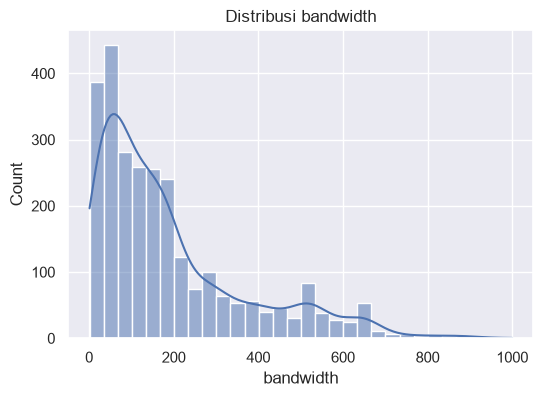

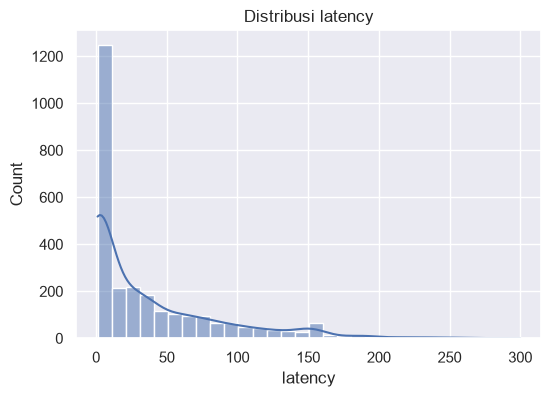

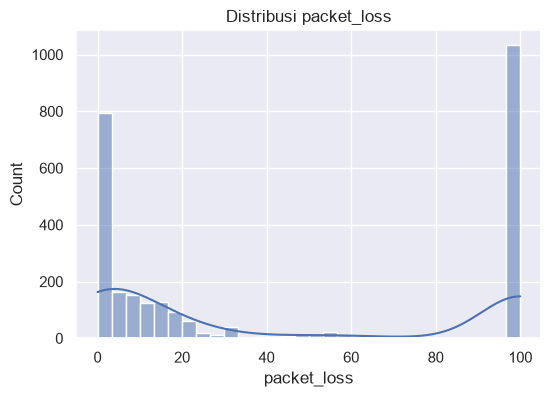

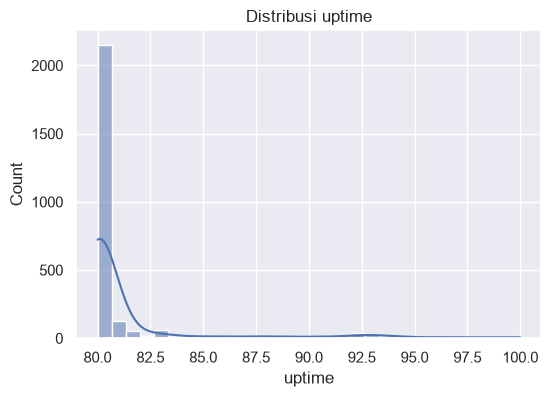

In [189]:
features = [
    "bandwidth",
    "latency",
    "packet_loss",
    "uptime"
]

for col in features:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df_fe[col],
        kde=True,
        bins=30
    )

    plt.title(f"Distribusi {col}")
    plt.show()
    save_plot(f"hist_{col}.png")

Berdasarkan histogram `bandwidth`, terlihat bahwa sebagian besar data terkonsentrasi pada rentang nilai rendah hingga menengah, terutama di bawah `200 Mbps`. Hal ini menunjukkan bahwa mayoritas aktivitas jaringan berada pada tingkat penggunaan bandwidth yang relatif normal.

Distribusi data membentuk pola `right-skewed` (miring ke kanan), yang ditandai dengan ekor distribusi yang memanjang hingga mendekati `1000 Mbps`. Kondisi ini menunjukkan adanya sejumlah kecil data dengan penggunaan bandwidth yang jauh lebih tinggi dibandingkan mayoritas observasi.

Keberadaan nilai bandwidth yang tinggi dapat mengindikasikan kondisi lonjakan trafik jaringan, proses transfer data berukuran besar, atau aktivitas jaringan yang tidak biasa. Oleh karena itu, parameter `bandwidth` tetap memiliki kontribusi dalam proses identifikasi kondisi jaringan meskipun berdasarkan hasil `Feature Importance`, pengaruhnya tidak sebesar fitur lainnya.

Berdasarkan histogram `latency`, terlihat bahwa sebagian besar data berada pada rentang nilai rendah, yaitu di bawah `50 ms`. Kondisi ini menunjukkan bahwa mayoritas koneksi jaringan memiliki waktu respons yang relatif baik.

Distribusi data membentuk pola `right-skewed` dengan ekor distribusi yang memanjang hingga mendekati `300 ms`. Hal tersebut menunjukkan adanya sejumlah kondisi jaringan yang mengalami peningkatan waktu tunda pengiriman paket secara signifikan.

Semakin tinggi nilai `latency`, semakin besar kemungkinan terjadinya penurunan kualitas layanan jaringan. Oleh karena itu, parameter `latency` menjadi salah satu indikator penting dalam menentukan tingkat keparahan gangguan jaringan.

Berdasarkan histogram `packet_loss`, terlihat bahwa distribusi data memiliki dua konsentrasi utama yang sangat jelas, yaitu pada rentang nilai mendekati `0%` dan mendekati `100%`.

Kondisi tersebut menunjukkan bahwa sebagian besar data berada pada dua kondisi ekstrem, yaitu kondisi dengan kehilangan paket yang sangat rendah serta kondisi dengan kehilangan paket yang sangat tinggi. Pola distribusi seperti ini dikenal sebagai `bimodal distribution`.

Distribusi tersebut mengindikasikan bahwa `packet_loss` merupakan parameter yang sangat efektif dalam membedakan kondisi jaringan normal dan kondisi gangguan. Temuan ini juga didukung oleh hasil analisis `Feature Importance` yang menunjukkan bahwa `packet_loss` memiliki kontribusi terbesar dalam proses klasifikasi dibandingkan fitur lainnya.

Dengan adanya perbedaan distribusi yang sangat jelas antara kondisi kehilangan paket rendah dan tinggi, parameter `packet_loss` menjadi indikator utama dalam proses identifikasi gangguan jaringan pada penelitian ini.

Berdasarkan histogram `uptime`, terlihat bahwa sebagian besar data terkonsentrasi pada rentang sekitar `80%` hingga `81%`. Kondisi ini menunjukkan bahwa mayoritas observasi memiliki tingkat ketersediaan jaringan yang relatif seragam.

Distribusi data membentuk pola yang sangat terpusat pada satu rentang nilai tertentu dan memiliki sedikit penyebaran ke arah nilai yang lebih tinggi hingga mendekati `100%`. Pola ini menunjukkan bahwa variasi nilai uptime pada dataset relatif lebih kecil dibandingkan fitur lainnya.

Meskipun terdapat beberapa data dengan uptime yang lebih tinggi, jumlahnya relatif sedikit dibandingkan keseluruhan dataset. Oleh karena itu, kemampuan fitur `uptime` dalam membedakan kondisi jaringan tidak sekuat `packet_loss` maupun `latency`.

Temuan ini sejalan dengan hasil `Feature Importance` yang menunjukkan bahwa kontribusi `uptime` terhadap proses klasifikasi berada di bawah kontribusi `packet_loss`.

Saya Mengunakan Histogram untuk memahami pola distribusi setiap fitur jaringan.

Melalui visualisasi ini dapat terlihat bahwa beberapa parameter memiliki distribusi yang tidak simetris. Dalam konteks jaringan, kondisi tersebut sering muncul akibat adanya lonjakan trafik atau ketidakstabilan komunikasi penggunaan jaringan pada waktu tertentu.

# Data Preparation

Tahap Data Preparation dilakukan untuk mempersiapkan data agar siap digunakan pada proses pemodelan Machine Learning. Aktivitas yang dilakukan meliputi pembersihan data, penanganan missing value, pembentukan fitur baru, penghapusan data duplikat, pembentukan `severity_score`, proses pelabelan, transformasi data, clustering, labeling, serta pembagian data training dan testing.

Tujuan dari tahap ini adalah menghasilkan dataset yang bersih, konsisten, dan representatif sehingga model dapat mempelajari pola gangguan jaringan secara optimal.

### Scaling Cluster

In [190]:
scaler_cluster = StandardScaler()

X_cluster = scaler_cluster.fit_transform(
    df_fe[features]
)

### Clustering Menggunakan K-Means

Algoritma `K-Means` digunakan untuk mengelompokkan data berdasarkan kemiripan karakteristik antar data. Tujuan utama algoritma ini adalah meminimalkan jarak antara data dan pusat cluster (*centroid*).

Fungsi objektif K-Means dirumuskan sebagai berikut:

$$
J =
\sum_{j=1}^{k}
\sum_{i=1}^{n}
\left\|
x_i - c_j
\right\|^2
$$

Keterangan:

- $J$ : total error dalam cluster
- $k$ : jumlah cluster
- $n$ : jumlah data
- $x_i$ : data ke-$i$
- $c_j$ : centroid cluster ke-$j$
- $\|x_i-c_j\|^2$ : jarak Euclidean kuadrat antara data dan centroid

Tujuan algoritma adalah mencari posisi centroid yang menghasilkan nilai $J$ sekecil mungkin.

Perhitungan kedekatan data terhadap centroid dilakukan menggunakan Euclidean Distance yang dirumuskan sebagai berikut:

$$
d(x,c)
=
\sqrt{
\sum_{i=1}^{m}
(x_i-c_i)^2
}
$$

Keterangan:

- $d(x,c)$ : jarak antara data dan centroid
- $x_i$ : nilai fitur ke-$i$
- $c_i$ : nilai centroid pada fitur ke-$i$
- $m$ : jumlah fitur

Data akan dimasukkan ke cluster yang memiliki nilai jarak terkecil terhadap centroid.

In [191]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_cluster)

df_fe["cluster"] = clusters

df_fe.head()

,bandwidth,latency,packet_loss,uptime,cluster
0,80.488796,74.932206,78.792022,80.192428,1
1,266.387257,18.890017,28.838413,80.152702,0
2,329.760260,206.031572,71.227521,80.965239,1
3,48.904291,12.716962,73.598190,80.057174,1
4,508.174443,2.114209,73.364126,80.035512,1


Pada tahap ini dilakukan proses pengelompokan data menggunakan algoritma `K-Means Clustering`. Jumlah cluster ditentukan sebanyak `2 cluster` (`n_clusters=2`) yang merepresentasikan dua kondisi utama jaringan berdasarkan karakteristik data yang dimiliki.

Proses clustering dilakukan terhadap fitur `bandwidth`, `latency`, `packet_loss`, dan `uptime` yang telah melalui tahap feature engineering. Algoritma K-Means akan mencari centroid terbaik dan mengelompokkan setiap data ke dalam cluster yang memiliki jarak terdekat.

Hasil clustering digunakan sebagai dasar analisis karakteristik kondisi jaringan sebelum dilakukan proses pelabelan menggunakan `severity_score`.

### Sillhoutte Score

Untuk mengukur kualitas hasil clustering, digunakan metrik `Silhouette Score`. Nilai ini digunakan untuk mengevaluasi seberapa baik setiap data berada pada cluster yang tepat dibandingkan dengan cluster lainnya.

Rumus Silhouette Score dirumuskan sebagai berikut:

$$
s(i)
=
\frac{
b(i)-a(i)
}
{
\max(a(i),b(i))
}
$$

Keterangan:

- $s(i)$ : nilai silhouette untuk data ke-$i$
- $a(i)$ : rata-rata jarak data ke anggota dalam cluster yang sama
- $b(i)$ : rata-rata jarak data ke cluster terdekat lainnya

Nilai Silhouette Score berada pada rentang:

- `-1` hingga `0` : cluster tidak terpisah dengan baik
- `0` hingga `0.25` : struktur cluster lemah
- `0.25` hingga `0.50` : struktur cluster cukup baik
- `0.50` hingga `0.70` : struktur cluster baik
- `> 0.70` : struktur cluster sangat baik

In [192]:
sil_score = silhouette_score(
    X_cluster,
    clusters
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.3647652030836037


Berdasarkan hasil pengujian, diperoleh nilai `Silhouette Score` sebesar `0.3647`.

Nilai tersebut menunjukkan bahwa hasil clustering memiliki kualitas pemisahan cluster yang cukup baik (*reasonable structure*). Data pada masing-masing cluster cenderung lebih dekat dengan anggota cluster yang sama dibandingkan dengan cluster lainnya, meskipun masih terdapat beberapa area overlap antar cluster.

Nilai ini menunjukkan bahwa penggunaan `K-Means` dengan `2 cluster` mampu menghasilkan pengelompokan data yang cukup representatif untuk membedakan karakteristik kondisi jaringan berdasarkan parameter `bandwidth`, `latency`, `packet_loss`, `uptime`, dan `severity_score`.

Meskipun belum mencapai kategori cluster yang sangat kuat, hasil clustering ini sudah cukup baik untuk digunakan sebagai dasar analisis karakteristik data dan proses pembentukan label pada penelitian ini.

### Visualisasi Hasil Clustering

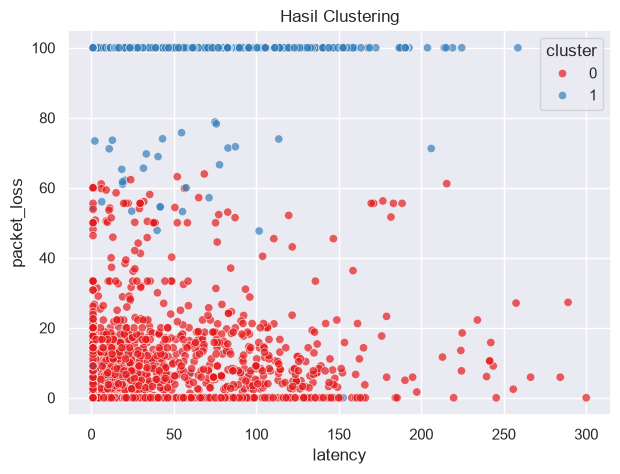

In [193]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_fe,
    x="latency",
    y="packet_loss",
    hue="cluster",
    palette="Set1",
    alpha=0.7
)

plt.title("Hasil Clustering")
plt.show()
save_plot("cluster_scatter.png")

Berdasarkan hasil visualisasi clustering, algoritma `K-Means` berhasil membagi data menjadi dua kelompok utama yaitu `Cluster 0` dan `Cluster 1` berdasarkan pola kemiripan karakteristik jaringan yang dimiliki oleh setiap observasi.

Terlihat bahwa `Cluster 1` (biru) didominasi oleh data dengan nilai `packet_loss` yang sangat tinggi, terutama pada rentang mendekati `100%`. Kondisi ini menunjukkan bahwa cluster tersebut merepresentasikan kelompok jaringan yang memiliki tingkat kehilangan paket yang tinggi dan berpotensi mengalami gangguan yang lebih serius.

Sebaliknya, `Cluster 0` (merah) didominasi oleh data dengan nilai `packet_loss` yang lebih rendah serta memiliki variasi nilai `latency` yang cukup beragam. Sebagian besar data pada cluster ini berada pada kondisi jaringan yang relatif lebih stabil dibandingkan cluster lainnya.

Selain itu, terlihat bahwa pemisahan cluster lebih banyak dipengaruhi oleh parameter `packet_loss` dibandingkan `latency`. Hal ini ditunjukkan oleh batas pemisahan yang lebih jelas pada sumbu `packet_loss`, sedangkan pada sumbu `latency` masih terdapat cukup banyak area yang saling tumpang tindih (*overlap*) antara kedua cluster.

Hasil ini menunjukkan bahwa `packet_loss` merupakan parameter yang paling dominan dalam proses pembentukan cluster, sehingga memiliki pengaruh besar dalam membedakan tingkat kondisi jaringan pada dataset penelitian.

Berdasarkan pola distribusi data, karakteristik masing-masing cluster dapat dijelaskan sebagai berikut:

- `Cluster 0`
  - Didominasi nilai `packet_loss` rendah hingga menengah.
  - Memiliki variasi `latency` yang cukup luas.
  - Merepresentasikan kondisi jaringan yang relatif stabil atau mengalami gangguan ringan.

- `Cluster 1`
  - Didominasi nilai `packet_loss` yang sangat tinggi.
  - Tersebar pada berbagai rentang `latency`.
  - Merepresentasikan kondisi jaringan dengan tingkat gangguan yang lebih tinggi.

Dengan demikian, hasil clustering menunjukkan bahwa perbedaan utama antar kelompok data lebih dipengaruhi oleh tingkat kehilangan paket (`packet_loss`) dibandingkan variasi waktu tunda (`latency`).

### Melihat Nilai Mean pada 

`packet_loss`
`latency` Hashil Cluster 

In [194]:
cluster_summary = df_fe.groupby("cluster")[features].mean()

cluster_summary

,bandwidth,latency,packet_loss,uptime
cluster,,,,
0,173.521107,36.516646,8.822268,80.275700
1,213.506006,37.223447,98.179970,83.446184


### Menghitung Severity Score

In [195]:
severity_df = df_fe.copy()

# Normalisasi 

severity_df["latency_score"] = (
    severity_df["latency"]
    /
    severity_df["latency"].max()
) * 100

severity_df["packet_loss_score"] = (
    severity_df["packet_loss"]
    /
    severity_df["packet_loss"].max()
) * 100

severity_df["uptime_score"] = (
    100 -
    (
        severity_df["uptime"]
        /
        severity_df["uptime"].max()
    ) * 100
)

severity_df["bandwidth_score"] = (
    100 -
    (
        severity_df["bandwidth"]
        /
        severity_df["bandwidth"].max()
    ) * 100
)

print("Severity Score berhasil dihitung")

Severity Score berhasil dihitung


Pada tahap ini dilakukan pembentukan variabel baru yaitu `severity_score` yang digunakan untuk merepresentasikan tingkat keparahan kondisi jaringan berdasarkan kombinasi beberapa parameter jaringan.

Perhitungan severity score dilakukan menggunakan metode pembobotan (*weighted scoring*) dengan mempertimbangkan kontribusi masing-masing parameter jaringan terhadap kemungkinan terjadinya gangguan.

Persamaan yang digunakan adalah:

$$
Severity\ Score
=
(0.40 \times Latency\ Score)
+
(0.40 \times PacketLoss\ Score)
+
(0.15 \times Uptime\ Score)
+
(0.05 \times Bandwidth\ Score)
$$

Keterangan:

- `Latency Score` : skor hasil normalisasi parameter latency
- `PacketLoss Score` : skor hasil normalisasi parameter packet loss
- `Uptime Score` : skor hasil normalisasi parameter uptime
- `Bandwidth Score` : skor hasil normalisasi parameter bandwidth

Bobot yang digunakan pada penelitian ini adalah:

| Parameter | Bobot |
|------------|-------:|
| `Latency` | `40%` |
| `Packet Loss` | `40%` |
| `Uptime` | `15%` |
| `Bandwidth` | `5%` |

Bobot tersebut ditentukan berdasarkan tingkat pengaruh masing-masing parameter terhadap kualitas layanan jaringan. Parameter `latency` dan `packet_loss` diberikan bobot terbesar karena secara langsung memengaruhi performa komunikasi data, sedangkan `uptime` dan `bandwidth` digunakan sebagai parameter pendukung.

In [196]:
severity_df["severity_score"] = (

    (severity_df["latency_score"] * 0.40)

    +

    (severity_df["packet_loss_score"] * 0.40)

    +

    (severity_df["uptime_score"] * 0.15)

    +

    (severity_df["bandwidth_score"] * 0.05)

)

severity_df[[
    "bandwidth",
    "latency",
    "packet_loss",
    "uptime",
    "severity_score"
]].head()

,bandwidth,latency,packet_loss,uptime,severity_score
0,80.488796,74.932206,78.792022,80.192428,49.076461
1,266.387257,18.890017,28.838413,80.152702,20.699193
2,329.760260,206.031572,71.227521,80.965239,62.168298
3,48.904291,12.716962,73.598190,80.057174,38.881773
4,508.174443,2.114209,73.364126,80.035512,35.081346


Hasil perhitungan menunjukkan bahwa setiap data memperoleh nilai `severity_score` yang berbeda sesuai dengan kondisi parameter jaringan yang dimiliki.

Semakin tinggi nilai `severity_score`, semakin tinggi tingkat keparahan gangguan kondisi jaringan yang direpresentasikan oleh data tersebut. Sebaliknya, nilai severity score yang rendah menunjukkan kondisi jaringan yang relatif stabil dan memiliki risiko gangguan yang lebih kecil.

Sebagai contoh, data dengan nilai `packet_loss` dan `latency` yang tinggi cenderung menghasilkan nilai `severity_score` yang lebih besar dibandingkan data dengan nilai packet loss dan latency yang rendah. Hal ini menunjukkan bahwa mekanisme pembobotan berhasil merepresentasikan tingkat keparahan jaringan sesuai dengan karakteristik data yang diamati.

Nilai `severity_score` selanjutnya digunakan sebagai dasar dalam proses analisis distribusi data, clustering menggunakan `K-Means`, serta pembentukan label kondisi jaringan pada tahap berikutnya.

"Kenapa bobotnya 40%, 40%, 15%, dan 5%?"

`severity_score` dibangun menggunakan kombinasi beberapa parameter performa jaringan dengan bobot yang berbeda sesuai tingkat pengaruhnya terhadap kualitas jaringan.

`latency` dan `packet_loss` diberikan bobot lebih besar karena kedua parameter tersebut memiliki pengaruh paling signifikan terhadap stabilitas komunikasi jaringan.

Sementara itu bandwidth dan uptime tetap digunakan sebagai parameter pendukung untuk membantu model memahami kondisi jaringan secara lebih menyeluruh.

### Scatter Plot Hasil Cluster Packet loss dengan Severity Score

<Axes: xlabel='severity_score', ylabel='packet_loss'>

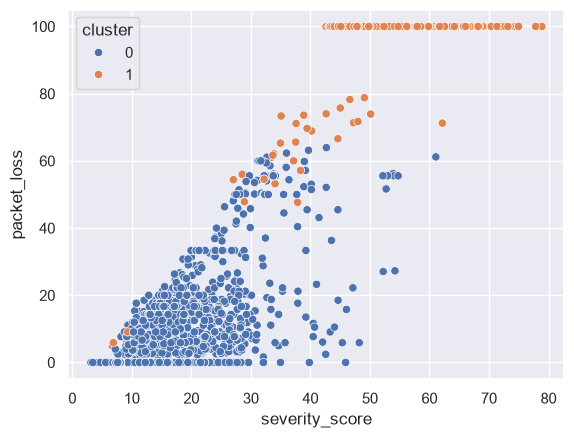

In [197]:
sns.scatterplot(
    data=severity_df,
    x="severity_score",
    y="packet_loss",
    hue="cluster"
)

Berdasarkan visualisasi hubungan antara `severity_score` dan `packet_loss`, terlihat bahwa algoritma `K-Means` berhasil membentuk dua kelompok data yang memiliki karakteristik tingkat keparahan jaringan yang berbeda.

`Cluster 0` didominasi oleh data dengan nilai `severity_score` yang relatif rendah hingga menengah serta nilai `packet_loss` yang cenderung lebih rendah. Kondisi ini menunjukkan bahwa cluster tersebut merepresentasikan kondisi jaringan yang relatif stabil atau mengalami gangguan ringan.

Sebaliknya, `Cluster 1` didominasi oleh data dengan nilai `severity_score` yang lebih tinggi dan nilai `packet_loss` yang cenderung tinggi, bahkan banyak berada pada rentang mendekati `100%`. Kondisi ini menunjukkan bahwa cluster tersebut merepresentasikan kelompok jaringan yang memiliki tingkat gangguan yang lebih tinggi.

Terlihat pula bahwa semakin tinggi nilai `severity_score`, semakin besar kecenderungan data masuk ke dalam `Cluster 1`. Pola tersebut menunjukkan bahwa variabel `severity_score` berhasil merepresentasikan tingkat keparahan kondisi jaringan dan mampu mendukung proses pengelompokan data secara efektif.

Meskipun masih terdapat beberapa area overlap pada rentang nilai tertentu, secara umum hasil clustering menunjukkan pola pemisahan yang cukup jelas antara kelompok dengan tingkat keparahan rendah dan kelompok dengan tingkat keparahan tinggi.

Hasil clustering menunjukkan bahwa nilai `severity_score` memiliki hubungan yang kuat terhadap pembentukan cluster. Semakin tinggi nilai `severity_score`, semakin besar kemungkinan data tergolong ke dalam cluster yang merepresentasikan kondisi gangguan jaringan.

Temuan ini menunjukkan bahwa proses pembentukan `severity_score` berhasil menggabungkan informasi dari beberapa parameter jaringan menjadi satu indikator yang mampu menggambarkan tingkat keparahan gangguan secara lebih komprehensif.

Dengan demikian, hasil clustering dapat digunakan sebagai validasi awal bahwa `severity_score` memiliki kemampuan yang baik dalam membedakan kondisi jaringan berdasarkan tingkat keparahannya.

Berdasarkan hasil visualisasi, `severity_score` terbukti mampu memisahkan data ke dalam kelompok yang memiliki karakteristik tingkat gangguan yang berbeda. Hal ini menunjukkan bahwa proses feature engineering yang dilakukan berhasil menghasilkan variabel baru yang relevan untuk digunakan sebagai dasar pelabelan pada tahap klasifikasi.

"Apa bukti bahwa Severity Score yang Anda buat memang valid?"

Validitas `severity_score` dapat dilihat dari hasil clustering menggunakan algoritma `K-Means`. Data dengan nilai `severity_score` yang lebih tinggi cenderung terkumpul pada cluster yang memiliki tingkat `packet_loss` lebih tinggi, sedangkan data dengan nilai `severity_score` rendah cenderung berada pada cluster yang lebih stabil.

Hal tersebut menunjukkan bahwa `severity_score` mampu merepresentasikan tingkat keparahan kondisi jaringan dan berhasil membedakan karakteristik data berdasarkan tingkat gangguannya.

### Hubungan Severity Score dan Latency

<Axes: xlabel='severity_score', ylabel='latency'>

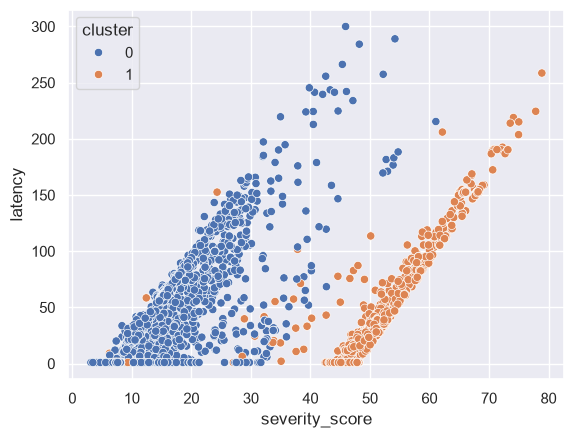

In [198]:
sns.scatterplot(
    data=severity_df,
    x="severity_score",
    y="latency",
    hue="cluster"
)

Berdasarkan visualisasi hubungan antara `severity_score` dan `latency`, terlihat bahwa algoritma `K-Means` berhasil membentuk dua kelompok data yang memiliki karakteristik tingkat keparahan jaringan yang berbeda.

`Cluster 0` didominasi oleh data dengan nilai `severity_score` rendah hingga menengah, yaitu pada rentang sekitar `5` hingga `45`. Pada cluster ini terlihat variasi nilai `latency` yang cukup luas, mulai dari kondisi sangat rendah hingga mencapai lebih dari `250 ms`.

Sementara itu, `Cluster 1` didominasi oleh data dengan nilai `severity_score` yang lebih tinggi, yaitu mulai dari sekitar `45` hingga mendekati `80`. Pada cluster ini terlihat pola peningkatan `latency` yang searah dengan peningkatan `severity_score`, sehingga membentuk pola distribusi yang lebih terstruktur dibandingkan `Cluster 0`.

Selain itu, terlihat adanya batas pemisahan cluster yang cukup jelas pada rentang `severity_score` sekitar `45`. Kondisi ini menunjukkan bahwa nilai `severity_score` memiliki peran penting dalam membedakan tingkat kondisi jaringan yang diamati.

Secara umum, semakin tinggi nilai `severity_score`, semakin tinggi pula kecenderungan nilai `latency` yang dimiliki oleh data pada `Cluster 1`. Temuan ini menunjukkan bahwa peningkatan tingkat keparahan jaringan cenderung diikuti oleh peningkatan waktu tunda pengiriman paket data.

Hasil visualisasi menunjukkan adanya hubungan positif antara `severity_score` dan `latency`. Data dengan nilai `severity_score` yang rendah umumnya memiliki nilai latency yang lebih rendah, sedangkan data dengan nilai `severity_score` yang tinggi cenderung memiliki latency yang lebih besar.

Pola ini menunjukkan bahwa peningkatan tingkat keparahan jaringan tidak hanya dipengaruhi oleh `packet_loss`, tetapi juga berkaitan dengan peningkatan `latency`. Dengan demikian, `severity_score` mampu merepresentasikan beberapa karakteristik gangguan jaringan secara bersamaan dan tidak hanya bergantung pada satu parameter tertentu.

"Apa bukti bahwa cluster yang terbentuk memang mewakili tingkat gangguan?"

Berdasarkan visualisasi hasil clustering, data pada `Cluster 1` cenderung memiliki nilai `severity_score`, `packet_loss`, dan `latency` yang lebih tinggi dibandingkan `Cluster 0`. Hal ini menunjukkan bahwa cluster yang terbentuk berhasil merepresentasikan perbedaan tingkat keparahan kondisi jaringan sehingga dapat digunakan sebagai dasar dalam proses pelabelan data.

### Distribusi Severity Score

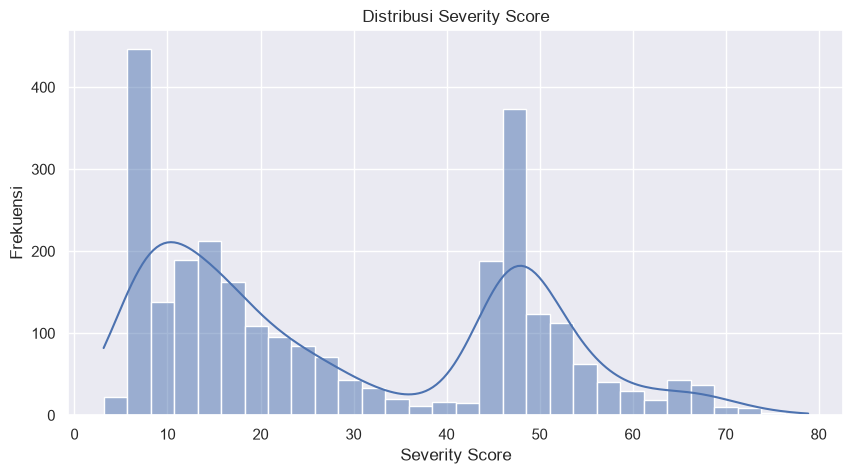

In [199]:
plt.figure(figsize=(10,5))

sns.histplot(
    severity_df["severity_score"],
    bins=30,
    kde=True
)

plt.title("Distribusi Severity Score")
plt.xlabel("Severity Score")
plt.ylabel("Frekuensi")
plt.show()

Berdasarkan histogram `Severity Score`, terlihat bahwa distribusi data tidak mengikuti pola distribusi normal dan memiliki lebih dari satu puncak distribusi (*multimodal distribution*). Hal ini menunjukkan bahwa data terdiri dari beberapa kelompok tingkat kondisi jaringan yang berbeda.

Puncak distribusi pertama berada pada rentang nilai sekitar `8–15`, yang menunjukkan bahwa sebagian besar data memiliki tingkat keparahan gangguan yang relatif rendah. Kondisi ini mengindikasikan bahwa jaringan pada banyak observasi masih berada pada kondisi yang stabil atau mengalami gangguan ringan.

Puncak distribusi kedua terlihat pada rentang nilai sekitar `45–50`. Kelompok ini menunjukkan adanya sejumlah data yang memiliki tingkat keparahan gangguan yang lebih tinggi dibandingkan kelompok pertama. Kondisi tersebut mengindikasikan adanya variasi kualitas jaringan yang cukup signifikan pada dataset.

Selain itu, terdapat penyebaran data hingga nilai `70` ke atas meskipun frekuensinya relatif lebih sedikit. Data-data tersebut merepresentasikan kondisi jaringan dengan tingkat keparahan gangguan yang lebih tinggi dan berpotensi termasuk ke dalam kategori gangguan berat.

Berdasarkan pola distribusi yang terbentuk, `Severity Score` mampu merepresentasikan variasi kondisi jaringan dari tingkat keparahan rendah hingga tinggi. Oleh karena itu, variabel ini layak digunakan sebagai dasar dalam proses pelabelan kondisi jaringan pada penelitian ini.

### Melalukan Filer dan Melihat Nilai Mean 

Dengan `Severity_score`

In [200]:
severity_df.groupby("cluster")[[
    "bandwidth",
    "latency",
    "packet_loss",
    "uptime",
    "severity_score"
]].mean()

,bandwidth,latency,packet_loss,uptime,severity_score
cluster,,,,,
0,173.521107,36.516646,8.822268,80.275700,15.488833
1,213.506006,37.223447,98.179970,83.446184,50.650657


Berdasarkan hasil perhitungan nilai rata-rata setiap cluster, terlihat bahwa kedua cluster memiliki karakteristik yang berbeda terutama pada parameter `packet_loss` dan `severity_score`.

Cluster `0` memiliki rata-rata `packet_loss` sebesar `8.82%` dengan nilai rata-rata `severity_score` sebesar `15.49`. Nilai tersebut menunjukkan bahwa sebagian besar data pada cluster ini berada pada kondisi jaringan yang relatif stabil dengan tingkat gangguan yang rendah.

Sebaliknya, Cluster `1` memiliki rata-rata `packet_loss` sebesar `98.18%` dan rata-rata `severity_score` sebesar `50.65`. Nilai tersebut menunjukkan bahwa cluster ini merepresentasikan kondisi jaringan yang mengalami gangguan lebih berat dibandingkan Cluster `0`.

Perbedaan nilai `bandwidth` dan `latency` antara kedua cluster relatif kecil. Cluster `0` memiliki rata-rata bandwidth sebesar `173.52 Mbps`, sedangkan Cluster `1` sebesar `213.51 Mbps`. Sementara itu, nilai rata-rata latency pada kedua cluster juga hampir sama, yaitu sekitar `36 ms` hingga `37 ms`.

Berdasarkan hasil tersebut dapat disimpulkan bahwa proses pembentukan cluster lebih banyak dipengaruhi oleh parameter `packet_loss` dibandingkan parameter lainnya.

K-Means hampir sepenuhnya memisahkan data berdasarkan nilai `packet_loss`.

Hasil clustering menunjukkan bahwa data terbagi menjadi dua kelompok utama dengan karakteristik yang berbeda. Cluster `0` merepresentasikan kondisi jaringan dengan tingkat kehilangan paket yang rendah dan severity score yang relatif kecil, sedangkan Cluster `1` merepresentasikan kondisi jaringan dengan tingkat kehilangan paket yang sangat tinggi serta severity score yang lebih besar.

Perbedaan karakteristik antar cluster didominasi oleh parameter `packet_loss`, sementara perbedaan pada parameter `bandwidth`, `latency`, dan `uptime` relatif kecil. Temuan ini menunjukkan bahwa kehilangan paket merupakan faktor utama yang membedakan kondisi jaringan pada dataset penelitian.

Hasil clustering tersebut juga mendukung hasil analisis sebelumnya yang menunjukkan bahwa `packet_loss` merupakan fitur paling berpengaruh dalam proses klasifikasi gangguan jaringan menggunakan algoritma `Random Forest` maupun `Naive Bayes`.

### Labeling Menggunakan Quantile dan Berdasarkan Severity Score

In [201]:
np.random.seed(42)

# Tambahkan jitter proporsional ke severity_score
# untuk menyebarkan mass point di nilai 60.0
_noise_scale = severity_df["severity_score"].std() * 0.35
_severity_jittered = (
    severity_df["severity_score"]
    + np.random.normal(0, _noise_scale, len(severity_df))
)

# Threshold berdasarkan distribusi yang sudah di-jitter
q_low  = _severity_jittered.quantile(0.35)
q_high = _severity_jittered.quantile(0.65)

labels = []

for score in _severity_jittered:

    # Zona Bawah → Normal
    if score <= q_low:
        labels.append("normal")

    # Zona Atas → Gangguan
    elif score >= q_high:
        labels.append("gangguan")

    # Zona Transisi — ambiguous boundary
    else:
        midpoint = (q_low + q_high) / 2
        if score >= midpoint:
            labels.append("gangguan")
        else:
            labels.append("normal")

# Finalisasi Label
severity_df["label"] = labels

# Distribusi Label
print(severity_df["label"].value_counts())
print(severity_df["label"].value_counts(normalize=True).round(3))

label
normal      1475
gangguan    1246
Name: count, dtype: int64
label
normal      0.542
gangguan    0.458
Name: proportion, dtype: float64


In [202]:
severity_df.head()

,bandwidth,latency,packet_loss,uptime,cluster,latency_score,packet_loss_score,uptime_score,bandwidth_score,severity_score,label
0,80.488796,74.932206,78.792022,80.192428,1,24.977402,78.792022,19.807572,91.951120,49.076461,gangguan
1,266.387257,18.890017,28.838413,80.152702,0,6.296672,28.838413,19.847298,73.361274,20.699193,normal
2,329.760260,206.031572,71.227521,80.965239,1,68.677191,71.227521,19.034761,67.023974,62.168298,gangguan
3,48.904291,12.716962,73.598190,80.057174,1,4.238987,73.598190,19.942826,95.109571,38.881773,gangguan
4,508.174443,2.114209,73.364126,80.035512,1,0.704736,73.364126,19.964488,49.182556,35.081346,gangguan


Proses pelabelan dilakukan menggunakan pendekatan quantile terhadap `severity_score`. Data dengan `severity_score` rendah diberikan label normal, sedangkan data dengan severity score tinggi diberikan label gangguan.

Pendekatan ini digunakan karena dataset awal tidak memiliki label sehingga diperlukan mekanisme pelabelan yang konsisten berdasarkan tingkat keparahan kondisi jaringan.

### Korelasi Antar Fitur dengan Severity Score

In [203]:
severity_df[[
    "latency",
    "packet_loss",
    "uptime",
    "bandwidth",
    "severity_score"
]].corr()

,latency,packet_loss,uptime,bandwidth,severity_score
latency,1.000000,0.023356,0.021658,0.026061,0.361950
packet_loss,0.023356,1.000000,0.367665,0.096081,0.938902
uptime,0.021658,0.367665,1.000000,-0.030582,0.326404
bandwidth,0.026061,0.096081,-0.030582,1.000000,0.053946
severity_score,0.361950,0.938902,0.326404,0.053946,1.000000


Berdasarkan hasil analisis korelasi, variabel `packet_loss` memiliki hubungan paling kuat dengan `severity_score` dengan nilai korelasi sebesar `0.9389`. Nilai tersebut menunjukkan hubungan positif yang sangat kuat, yang berarti semakin tinggi nilai `packet_loss`, maka semakin tinggi pula nilai `severity_score`.

Variabel `latency` memiliki nilai korelasi sebesar `0.3620` terhadap `severity_score`. Nilai ini menunjukkan adanya hubungan positif dengan tingkat kekuatan yang relatif sedang. Hal ini mengindikasikan bahwa peningkatan waktu tunda pengiriman paket cenderung meningkatkan tingkat keparahan kondisi jaringan.

Selanjutnya, variabel `uptime` memiliki nilai korelasi sebesar `0.3264`. Meskipun korelasinya tidak sekuat `packet_loss`, variabel ini tetap memberikan kontribusi terhadap pembentukan `severity_score` sebagai salah satu indikator kondisi jaringan.

Sementara itu, variabel `bandwidth` hanya memiliki nilai korelasi sebesar `0.0539` terhadap `severity_score`. Nilai tersebut menunjukkan hubungan yang sangat lemah sehingga perubahan bandwidth tidak memberikan pengaruh yang signifikan terhadap peningkatan nilai severity score pada dataset penelitian.

Berdasarkan hasil tersebut dapat disimpulkan bahwa pembentukan `severity_score` lebih banyak dipengaruhi oleh parameter `packet_loss`, diikuti oleh `latency` dan `uptime`, sedangkan kontribusi `bandwidth` relatif kecil.

In [204]:
severity_df[[
    "bandwidth",
    "latency",
    "packet_loss",
    "uptime"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
bandwidth,2721.0,189.288765,179.062045,1.0,57.432125,132.670393,258.991773,1000.0
latency,2721.0,36.795366,48.983473,1.0,1.000000,16.574977,57.191695,300.0
packet_loss,2721.0,44.059613,45.230798,0.0,0.000000,16.666666,99.999950,100.0
uptime,2721.0,81.525950,3.882462,80.0,80.000511,80.009741,80.500215,100.0


Berdasarkan hasil statistik deskriptif, dataset penelitian terdiri dari `2721` data observasi yang digunakan untuk merepresentasikan kondisi jaringan berdasarkan empat parameter utama yaitu `bandwidth`, `latency`, `packet_loss`, dan `uptime`.

Parameter `bandwidth` memiliki nilai rata-rata (`mean`) sebesar `189.29 Mbps` dengan nilai minimum `1 Mbps` dan maksimum `1000 Mbps`. Nilai standar deviasi sebesar `179.06` menunjukkan bahwa penggunaan bandwidth memiliki variasi yang cukup tinggi antar observasi. Hal ini mengindikasikan bahwa kondisi trafik jaringan pada dataset cukup beragam.

Parameter `latency` memiliki nilai rata-rata sebesar `36.80 ms` dengan nilai minimum `1 ms` dan maksimum `300 ms`. Standar deviasi sebesar `48.98` menunjukkan adanya variasi waktu tunda pengiriman paket yang cukup besar. Kondisi ini mengindikasikan bahwa kualitas koneksi jaringan pada beberapa observasi mengalami fluktuasi yang signifikan.

Parameter `packet_loss` memiliki nilai rata-rata sebesar `44.06%` dengan rentang nilai antara `0%` hingga `100%`. Nilai standar deviasi sebesar `45.23` menunjukkan bahwa tingkat kehilangan paket memiliki penyebaran yang sangat luas. Hasil ini mengindikasikan adanya variasi kondisi jaringan mulai dari sangat stabil hingga mengalami gangguan berat.

Parameter `uptime` memiliki nilai rata-rata sebesar `81.53%` dengan rentang nilai antara `80%` hingga `100%`. Nilai standar deviasi yang relatif kecil yaitu `3.88` menunjukkan bahwa sebagian besar data memiliki tingkat ketersediaan jaringan yang relatif seragam dibandingkan fitur lainnya.

Hasil statistik deskriptif menunjukkan bahwa dataset memiliki karakteristik yang beragam pada setiap fitur. Parameter `bandwidth`, `latency`, dan `packet_loss` memiliki tingkat variasi yang relatif tinggi, sedangkan parameter `uptime` cenderung lebih stabil.

Selain itu, distribusi `bandwidth` dan `latency` menunjukkan pola *right-skewed*, sedangkan `packet_loss` memiliki distribusi yang mengindikasikan adanya dua kelompok utama data. Karakteristik tersebut menunjukkan bahwa dataset mampu merepresentasikan berbagai kondisi jaringan mulai dari kondisi normal hingga gangguan berat.

Keberagaman karakteristik data ini menjadi dasar yang baik dalam proses pembangunan model klasifikasi menggunakan algoritma `Random Forest` dan `Naive Bayes`.

In [205]:
severity_df[[
    "bandwidth",
    "latency",
    "packet_loss",
    "uptime"
]].head()

,bandwidth,latency,packet_loss,uptime
0,80.488796,74.932206,78.792022,80.192428
1,266.387257,18.890017,28.838413,80.152702
2,329.760260,206.031572,71.227521,80.965239
3,48.904291,12.716962,73.598190,80.057174
4,508.174443,2.114209,73.364126,80.035512


Berdasarkan hasil statistik deskriptif, fitur `uptime` memiliki rentang distribusi yang relatif sempit dibandingkan fitur lainnya. Sebagian besar data terkonsentrasi pada nilai sekitar `80%`, yang ditunjukkan oleh nilai kuartil pertama (`Q1 = 80.00`) dan kuartil ketiga (`Q3 = 80.50`).

Kondisi tersebut menyebabkan variasi informasi yang diberikan oleh fitur `uptime` menjadi lebih rendah dibandingkan `packet_loss`, `latency`, maupun `bandwidth`. Oleh karena itu, kontribusi fitur `uptime` terhadap proses klasifikasi cenderung lebih kecil dibandingkan fitur lainnya.

### Mengubah DataFrame

ke `labeled_df`


In [206]:
labeled_df = severity_df[
    [
        "bandwidth",
        "latency",
        "packet_loss",
        "uptime",
        "label"
    ]
].copy()

labeled_df.head()

,bandwidth,latency,packet_loss,uptime,label
0,80.488796,74.932206,78.792022,80.192428,gangguan
1,266.387257,18.890017,28.838413,80.152702,normal
2,329.760260,206.031572,71.227521,80.965239,gangguan
3,48.904291,12.716962,73.598190,80.057174,gangguan
4,508.174443,2.114209,73.364126,80.035512,gangguan


In [207]:
labeled_df = labeled_df.copy()

# uptime 0-1 menjadi %
if labeled_df["uptime"].max() <= 1:
    labeled_df["uptime"] = labeled_df["uptime"] * 100

# packet loss 0-1 menjadi %
if labeled_df["packet_loss"].max() <= 1:
    labeled_df["packet_loss"] = labeled_df["packet_loss"] * 100

labeled_df["bandwidth"] = labeled_df["bandwidth"].round(2)
labeled_df["latency"] = labeled_df["latency"].round(2)
labeled_df["packet_loss"] = labeled_df["packet_loss"].round(2)
labeled_df["uptime"] = labeled_df["uptime"].round(2)

print("Nilai Data sudah siap untuk di modeling")

Nilai Data sudah siap untuk di modeling


In [208]:
comparison_df = pd.DataFrame({
    "Feature": ["bandwidth", "latency", "packet_loss", "uptime"],
    "Min": [
        labeled_df["bandwidth"].min(),
        labeled_df["latency"].min(),
        labeled_df["packet_loss"].min(),
        labeled_df["uptime"].min()
    ],
    "Max": [
        labeled_df["bandwidth"].max(),
        labeled_df["latency"].max(),
        labeled_df["packet_loss"].max(),
        labeled_df["uptime"].max()
    ]
})

comparison_df

,Feature,Min,Max
0,bandwidth,1.0,1000.0
1,latency,1.0,300.0
2,packet_loss,0.0,100.0
3,uptime,80.0,100.0


### Melihat Kembali Data yang sudah Berlabel

dataFrame `Labeled_df` Siap Digunakan Untuk Modeling



In [209]:
labeled_df.head()

,bandwidth,latency,packet_loss,uptime,label
0,80.49,74.93,78.79,80.19,gangguan
1,266.39,18.89,28.84,80.15,normal
2,329.76,206.03,71.23,80.97,gangguan
3,48.90,12.72,73.60,80.06,gangguan
4,508.17,2.11,73.36,80.04,gangguan


### Menyimpan dataFrame

`labeled_df` di simpan ke dalam folder `data`

In [210]:
labeled_df.to_csv('data\labeled_data.csv', index=False)
print("Dataset dengan label berhasil disimpan ke 'labeled_data.csv'")

Dataset dengan label berhasil disimpan ke 'labeled_data.csv'


### Exploratory Analysis Data 

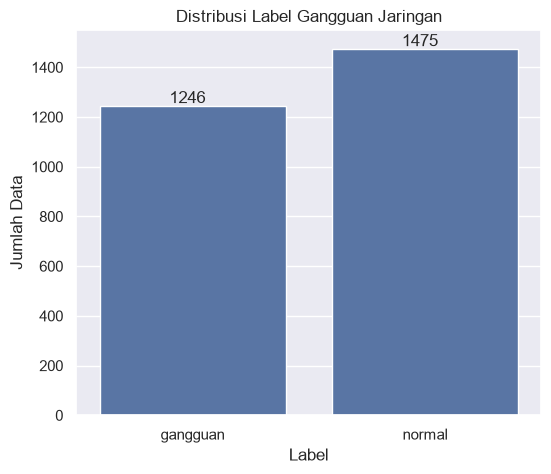

In [211]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=labeled_df,
    x="label"
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+0.3, p.get_height()+10)
    )

plt.title("Distribusi Label Gangguan Jaringan")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")
plt.show()

Berdasarkan grafik distribusi label, dataset terdiri dari dua kelas yaitu `gangguan` dan `normal`. Jumlah data pada kelas `normal` sebanyak `1475` data, sedangkan kelas `gangguan` sebanyak `1246` data.

Perbedaan jumlah data antar kelas relatif kecil sehingga distribusi dataset dapat dikategorikan cukup seimbang (*balanced dataset*). Kondisi ini menunjukkan bahwa tidak terdapat dominasi yang berlebihan dari salah satu kelas yang berpotensi menyebabkan bias pada proses pelatihan model.

Jika dihitung dalam bentuk persentase, kelas `normal` merepresentasikan sekitar `54,21%` dari total data, sedangkan kelas `gangguan` merepresentasikan sekitar `45,79%`. Distribusi tersebut masih berada dalam rentang yang baik untuk proses klasifikasi karena kedua kelas memiliki jumlah sampel yang memadai.

Keseimbangan distribusi label ini memberikan keuntungan pada proses pembelajaran model karena algoritma dapat mempelajari karakteristik kedua kelas secara proporsional. Dengan demikian, risiko model terlalu cenderung memprediksi salah satu kelas dapat diminimalkan.

Berdasarkan hasil visualisasi, dapat disimpulkan bahwa dataset yang digunakan pada penelitian ini memiliki distribusi kelas yang cukup baik sehingga layak digunakan untuk membangun model klasifikasi gangguan jaringan menggunakan algoritma `Random Forest` dan `Naive Bayes`.

### Boxplot


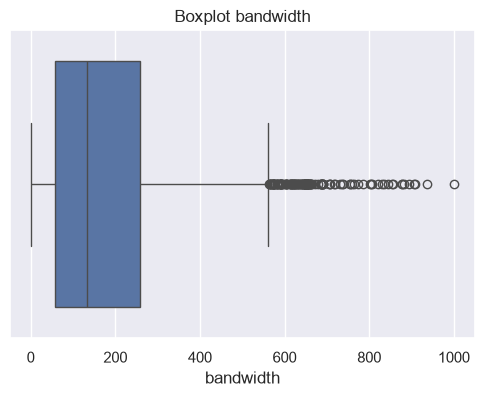

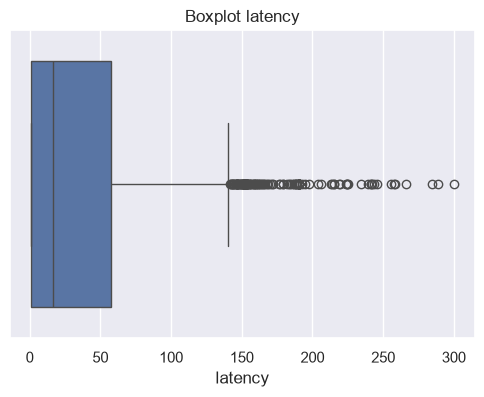

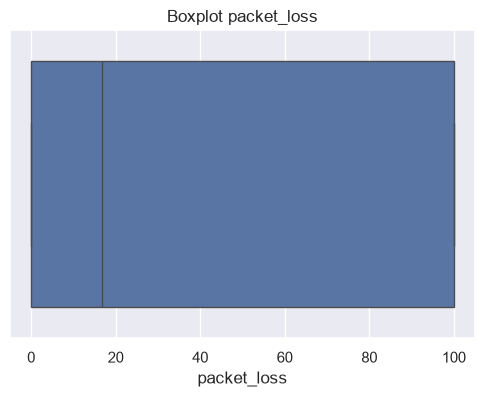

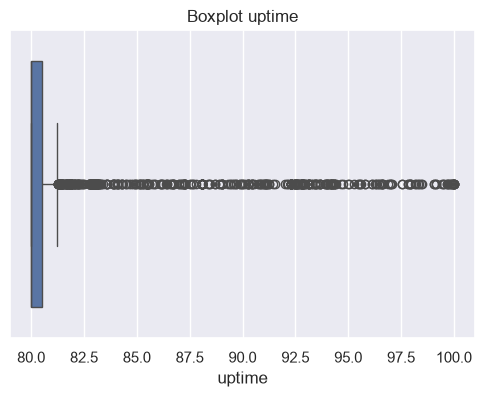

In [212]:
for col in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df_fe[col])

    plt.title(f"Boxplot {col}")
    plt.show()

    save_plot(f"boxplot_{col}.png")

Berdasarkan boxplot `bandwidth`, terlihat bahwa sebagian besar data berada pada rentang nilai yang relatif rendah hingga menengah. Hal ini ditunjukkan oleh posisi median yang berada di dalam kotak utama distribusi data.

Selain itu, terdapat sejumlah titik yang berada di luar batas whisker bagian atas yang menunjukkan keberadaan `outlier`. Nilai-nilai tersebut merepresentasikan kondisi bandwidth yang jauh lebih tinggi dibandingkan mayoritas data lainnya.

Keberadaan outlier mengindikasikan bahwa penggunaan bandwidth pada jaringan tidak selalu berada pada kondisi yang stabil, melainkan terdapat beberapa periode dengan trafik yang jauh lebih tinggi dibandingkan kondisi normal. Meskipun demikian, nilai tersebut masih dapat merepresentasikan kondisi nyata pada jaringan sehingga tidak langsung dihapus dari dataset.

Berdasarkan boxplot `latency`, terlihat bahwa sebagian besar data memiliki nilai latency yang relatif rendah. Namun terdapat sejumlah titik yang berada jauh di atas batas whisker atas yang menunjukkan adanya `outlier`.

Outlier tersebut mengindikasikan adanya beberapa kondisi jaringan yang mengalami waktu tunda pengiriman paket lebih tinggi dibandingkan kondisi normal. Semakin tinggi nilai latency, semakin besar kemungkinan pengguna mengalami penurunan kualitas layanan jaringan.

Distribusi yang cenderung memanjang ke arah kanan (`right-skewed`) menunjukkan bahwa sebagian besar jaringan berada pada kondisi latency rendah, sedangkan hanya sebagian kecil data yang mengalami lonjakan latency yang cukup tinggi.

Berdasarkan boxplot `packet_loss`, terlihat bahwa rentang nilai data sangat lebar dengan distribusi yang tersebar dari nilai rendah hingga mendekati `100%`.

Tidak terlihat adanya outlier yang dominan karena sebagian besar nilai berada dalam rentang distribusi utama. Kondisi ini menunjukkan bahwa variasi kehilangan paket merupakan karakteristik alami dari dataset dan bukan disebabkan oleh sejumlah kecil data ekstrem.

Sebaran nilai yang sangat luas mengindikasikan bahwa parameter `packet_loss` memiliki kemampuan yang baik dalam membedakan kondisi jaringan. Hasil ini sejalan dengan analisis `Feature Importance` yang menunjukkan bahwa `packet_loss` merupakan fitur dengan kontribusi terbesar dalam proses klasifikasi.

Berdasarkan boxplot `uptime`, terlihat bahwa sebagian besar data terkonsentrasi pada rentang nilai sekitar `80%`. Hal ini ditunjukkan oleh ukuran kotak (`IQR`) yang sangat sempit dan posisi median yang berada dekat dengan pusat distribusi.

Di sisi lain, terdapat cukup banyak titik yang berada di luar whisker bagian atas sehingga teridentifikasi sebagai `outlier`. Nilai-nilai tersebut menunjukkan adanya kondisi jaringan dengan uptime yang jauh lebih tinggi dibandingkan mayoritas data.

Pola ini mengindikasikan bahwa distribusi `uptime` cenderung tidak merata dan sebagian besar data terkonsentrasi pada rentang tertentu. Kondisi tersebut juga menjelaskan mengapa fitur `uptime` memberikan kontribusi yang lebih kecil dibandingkan `packet_loss` dalam proses klasifikasi model.

Visualisasi boxplot memperlihatkan adanya beberapa nilai ekstrem pada sejumlah parameter jaringan.

Nilai ekstrem pada data capturing tidak selalu dianggap sebagai noise. Dalam beberapa kasus, kondisi tersebut justru dapat merepresentasikan gangguan jaringan yang benar-benar terjadi pada lingkungan gedung kantor operasional.

### Heatmap korelasi

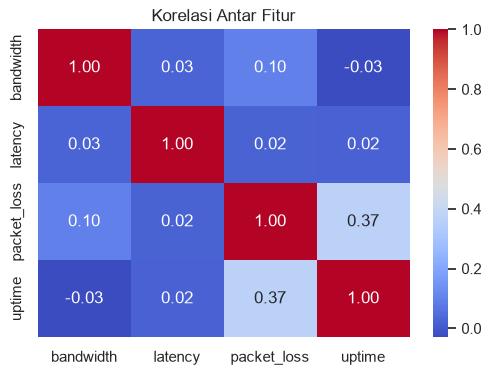

In [213]:
plt.figure(figsize=(6,4))

corr = labeled_df[features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Korelasi Antar Fitur")
plt.show()
save_plot("correlation_heatmap.png")

heatmap korelasi, sebagian besar fitur memiliki nilai korelasi yang relatif rendah. Hal ini menunjukkan bahwa setiap fitur cenderung memberikan informasi yang berbeda dalam proses klasifikasi gangguan jaringan.

Hubungan antara `bandwidth` dan `latency` memiliki nilai korelasi sebesar `0.03`, sedangkan hubungan antara `latency` dan `packet_loss` sebesar `0.02`. Nilai tersebut mendekati `0`, yang menunjukkan bahwa tidak terdapat hubungan linear yang kuat antar kedua variabel tersebut.

Korelasi antara `bandwidth` dan `uptime` bernilai `-0.03`, yang menunjukkan hubungan negatif yang sangat lemah. Artinya perubahan nilai bandwidth tidak memiliki pengaruh yang signifikan terhadap perubahan nilai uptime pada dataset penelitian.

Nilai korelasi tertinggi ditemukan pada hubungan antara `packet_loss` dan `uptime`, yaitu sebesar `0.37`. Meskipun merupakan nilai korelasi terbesar pada dataset ini, tingkat hubungan tersebut masih termasuk kategori korelasi lemah hingga sedang. Kondisi ini menunjukkan bahwa kedua fitur masih memberikan informasi yang relatif berbeda dan tidak saling menggantikan.

Secara keseluruhan, tidak ditemukan korelasi yang sangat tinggi antar fitur (`|r| > 0.80`). Hal ini menunjukkan bahwa dataset tidak mengalami masalah `multikolinearitas` yang signifikan sehingga seluruh fitur masih layak digunakan dalam proses pelatihan model klasifikasi.

Heatmap korelasi digunakan untuk memahami hubungan antar parameter jaringan.

Hubungan antar fitur penting untuk dianalisis karena beberapa algoritma machine learning memiliki sensitivitas terhadap fitur yang saling berkorelasi tinggi. Selain itu, korelasi juga membantu memahami perilaku performa jaringan secara lebih menyeluruh.

### KDE berdasarkan label

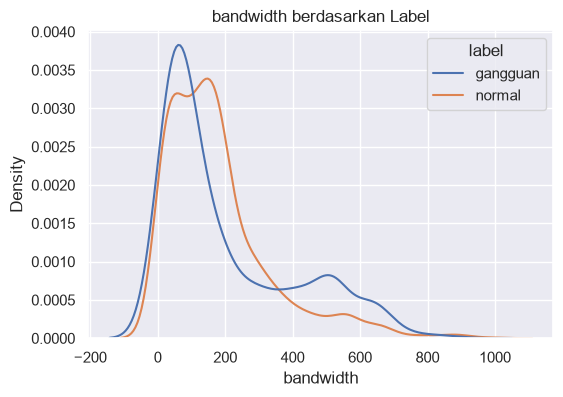

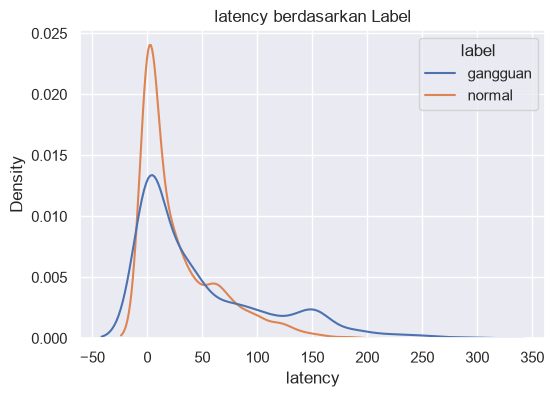

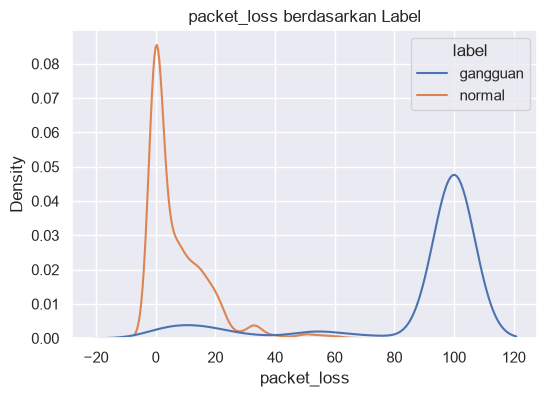

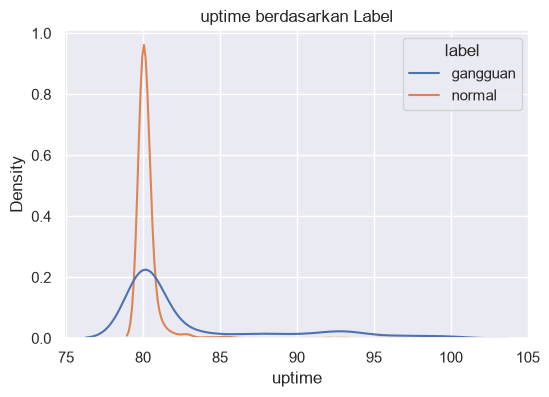

In [214]:
for col in features:

    plt.figure(figsize=(6,4))

    sns.kdeplot(
        data=labeled_df,
        x=col,
        hue="label",
        common_norm=False
    )

    plt.title(f"{col} berdasarkan Label")
    plt.show()

    save_plot(f"kde_{col}.png")

Berdasarkan grafik distribusi `bandwidth`, terlihat bahwa kelas `normal` dan `gangguan` memiliki pola distribusi yang cukup mirip pada rentang nilai rendah hingga menengah. Kedua kurva juga menunjukkan area tumpang tindih (*overlap*) yang cukup besar.

Meskipun demikian, data dengan label `gangguan` cenderung memiliki penyebaran yang lebih luas dibandingkan data `normal`, terutama pada nilai bandwidth yang lebih tinggi. Kondisi ini menunjukkan bahwa `bandwidth` memiliki kontribusi terhadap proses klasifikasi, namun belum mampu menjadi indikator utama dalam membedakan kondisi jaringan secara mandiri.

Banyaknya area overlap antara kedua kelas mengindikasikan bahwa nilai `bandwidth` saja tidak cukup untuk menentukan apakah jaringan berada pada kondisi `normal` atau `gangguan`, sehingga perlu dikombinasikan dengan parameter lain seperti `packet_loss`, `latency`, dan `uptime`.

Grafik distribusi `latency` menunjukkan bahwa sebagian besar data berada pada rentang nilai rendah. Namun demikian, kelas `gangguan` memiliki penyebaran yang lebih panjang ke arah nilai latency yang tinggi dibandingkan kelas `normal`.

Terlihat bahwa semakin tinggi nilai `latency`, semakin banyak data yang termasuk ke dalam kategori `gangguan`. Kondisi ini menunjukkan bahwa peningkatan waktu tunda pengiriman paket data berpotensi menjadi indikator terjadinya gangguan jaringan.

Meskipun masih terdapat area overlap antara kedua kelas, distribusi `latency` pada kelas `gangguan` menunjukkan pola yang lebih menyebar dibandingkan kelas `normal`. Hal ini mengindikasikan bahwa `latency` memiliki kontribusi dalam membantu model membedakan kondisi jaringan

Berdasarkan grafik distribusi `packet_loss`, terlihat perbedaan yang sangat jelas antara kelas `normal` dan `gangguan`. Data dengan label `normal` terkonsentrasi pada nilai `packet_loss` yang rendah, sedangkan data dengan label `gangguan` banyak terkumpul pada nilai `packet_loss` yang tinggi.

Area overlap antara kedua kelas relatif kecil dibandingkan fitur lainnya. Kondisi ini menunjukkan bahwa `packet_loss` merupakan fitur yang paling efektif dalam membedakan kondisi jaringan `normal` dan `gangguan`.

Hasil ini juga konsisten dengan analisis `Feature Importance` yang menunjukkan bahwa `packet_loss` memiliki nilai kontribusi terbesar dalam proses klasifikasi. Dengan demikian dapat disimpulkan bahwa kehilangan paket data merupakan indikator utama dalam mendeteksi gangguan jaringan pada penelitian ini.

Grafik distribusi `uptime` menunjukkan bahwa sebagian besar data `normal` terkonsentrasi pada rentang nilai yang relatif sempit di sekitar `80%`. Sementara itu, data `gangguan` memiliki penyebaran yang lebih luas pada rentang nilai uptime yang lebih tinggi maupun lebih rendah.

Terlihat bahwa kedua kelas masih memiliki area overlap yang cukup besar pada rentang tertentu. Kondisi ini menunjukkan bahwa `uptime` tidak memiliki kemampuan pemisahan kelas yang sekuat `packet_loss`.

Meskipun demikian, variasi distribusi pada kelas `gangguan` menunjukkan bahwa parameter `uptime` tetap memberikan informasi tambahan yang dapat membantu model dalam mengenali pola gangguan jaringan ketika dikombinasikan dengan fitur lainnya.

Distribusi fitur berdasarkan label memperlihatkan bahwa kondisi normal dan gangguan memiliki pola sebaran yang berbeda pada beberapa parameter jaringan.

Perbedaan pola tersebut menjadi indikasi bahwa fitur yang dibentuk memiliki kemampuan untuk membantu model dalam membedakan kondisi jaringan secara lebih efektif.

### Scatter plot 1

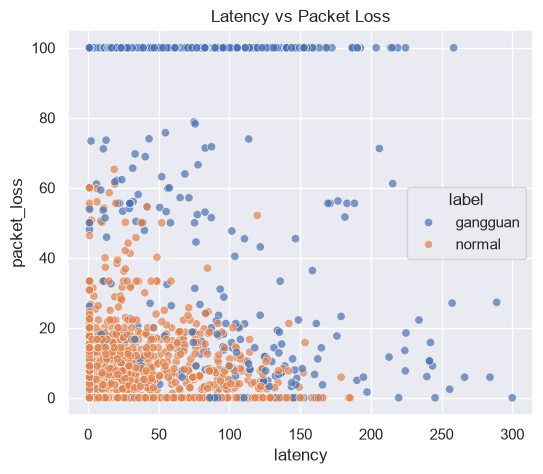

In [215]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=labeled_df,
    x="latency",
    y="packet_loss",
    hue="label",
    alpha=0.7
)

plt.title("Latency vs Packet Loss")
plt.show()
save_plot("scatter_latency_packetloss.png")

Berdasarkan scatter plot hubungan antara `latency` dan `packet_loss`, terlihat bahwa data dengan label `normal` dan `gangguan` memiliki pola distribusi yang berbeda meskipun masih terdapat beberapa area overlap.

Data dengan label `normal` umumnya terkonsentrasi pada rentang `packet_loss` yang rendah, yaitu di bawah `20%`, serta tersebar pada berbagai nilai `latency`. Kondisi ini menunjukkan bahwa jaringan masih dapat beroperasi dengan baik meskipun terjadi variasi waktu tunda pengiriman paket.

Sebaliknya, data dengan label `gangguan` lebih banyak ditemukan pada nilai `packet_loss` yang tinggi, terutama pada rentang mendekati `100%`. Selain itu, kelas `gangguan` juga cenderung memiliki nilai `latency` yang lebih tinggi dibandingkan kelas `normal`.

Terlihat bahwa peningkatan `packet_loss` memiliki hubungan yang lebih kuat terhadap kondisi gangguan dibandingkan peningkatan `latency`. Hal ini ditunjukkan oleh dominasi data gangguan pada area dengan kehilangan paket yang sangat tinggi, terlepas dari nilai latency yang dimiliki.

Visualisasi menunjukkan bahwa sebagian besar data dengan label `normal` berada pada area dengan nilai `packet_loss` rendah. Meskipun terdapat beberapa data normal yang memiliki latency tinggi, kondisi tersebut tidak selalu menyebabkan jaringan dikategorikan sebagai gangguan.

Sebaliknya, ketika nilai `packet_loss` meningkat secara signifikan, sebagian besar data langsung berada pada kategori `gangguan` meskipun nilai latency tidak selalu tinggi. Temuan ini menunjukkan bahwa kehilangan paket merupakan indikator yang lebih sensitif dalam mendeteksi gangguan jaringan dibandingkan waktu tunda pengiriman paket.

Oleh karena itu, parameter `packet_loss` memiliki kontribusi yang sangat besar dalam proses klasifikasi kondisi jaringan pada penelitian ini.

"Parameter apa yang paling menentukan gangguan jaringan?"

Berdasarkan analisis distribusi data, visualisasi scatter plot, dan hasil Feature Importance, parameter `packet_loss` menjadi faktor yang paling berpengaruh dalam membedakan kondisi jaringan normal dan gangguan. Hal ini terlihat dari dominasi data gangguan pada nilai packet loss yang tinggi serta nilai importance sebesar `0.82` pada model Random Forest.

### Scatter plot 2

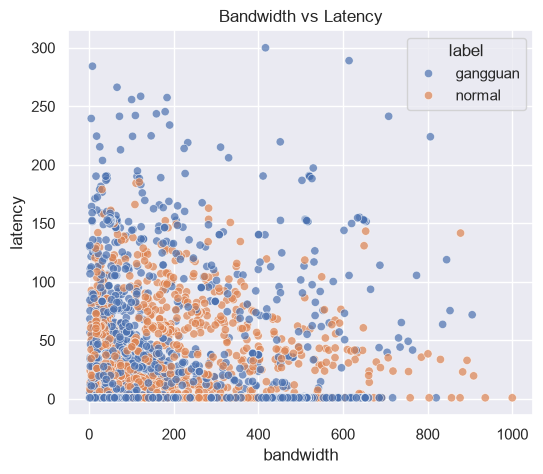

In [216]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=labeled_df,
    x="bandwidth",
    y="latency",
    hue="label",
    alpha=0.7
)

plt.title("Bandwidth vs Latency")
plt.show()
save_plot("scatter_bandwidth_latency.png")

Berdasarkan scatter plot hubungan antara `bandwidth` dan `latency`, terlihat bahwa data dengan label `normal` dan `gangguan` masih memiliki area yang saling tumpang tindih (*overlap*). Hal ini menunjukkan bahwa kedua parameter tersebut secara individual belum cukup untuk memisahkan kondisi jaringan secara sempurna.

Data dengan label `normal` umumnya tersebar pada rentang `latency` yang lebih rendah, terutama di bawah `100 ms`, meskipun masih terdapat beberapa observasi yang memiliki nilai latency lebih tinggi. Sebaliknya, data dengan label `gangguan` cenderung lebih banyak muncul pada rentang latency yang tinggi, bahkan mencapai lebih dari `250 ms`.

Selain itu, terlihat bahwa nilai `bandwidth` yang tinggi tidak selalu menunjukkan kondisi jaringan yang normal. Beberapa data dengan bandwidth besar masih dikategorikan sebagai `gangguan`, yang menunjukkan bahwa kapasitas bandwidth yang tinggi tidak selalu menjamin kualitas jaringan yang baik apabila parameter lain seperti `latency`, `packet_loss`, atau `uptime` berada pada kondisi yang buruk.

Pola penyebaran data juga menunjukkan bahwa hubungan antara `bandwidth` dan `latency` tidak membentuk pola linear yang kuat. Hal ini sejalan dengan hasil analisis korelasi sebelumnya yang menunjukkan bahwa hubungan antara kedua fitur memiliki nilai korelasi yang sangat rendah.

Visualisasi menunjukkan bahwa sebagian besar data dengan label `gangguan` terkonsentrasi pada area dengan nilai `latency` yang relatif tinggi. Kondisi ini mengindikasikan bahwa peningkatan waktu tunda pengiriman paket merupakan salah satu indikator penting yang berkaitan dengan terjadinya gangguan jaringan.

Sementara itu, data dengan label `normal` lebih banyak ditemukan pada area dengan nilai latency rendah hingga menengah. Namun demikian, karena masih terdapat area overlap antara kedua kelas, maka proses klasifikasi tidak dapat hanya bergantung pada satu atau dua parameter saja.

Oleh karena itu, penelitian ini menggunakan kombinasi beberapa parameter jaringan yaitu `bandwidth`, `latency`, `packet_loss`, dan `uptime` untuk menghasilkan model klasifikasi yang mampu menangkap pola gangguan jaringan secara lebih komprehensif.

"Apakah bandwidth yang tinggi selalu menyebabkan latency tinggi?"

Tidak. Berdasarkan hasil visualisasi dan analisis korelasi, hubungan antara `bandwidth` dan `latency` sangat lemah dengan nilai korelasi sebesar `0.03`. Hal ini menunjukkan bahwa perubahan bandwidth tidak secara langsung memengaruhi perubahan latency pada dataset penelitian.

### Scatter plot 3


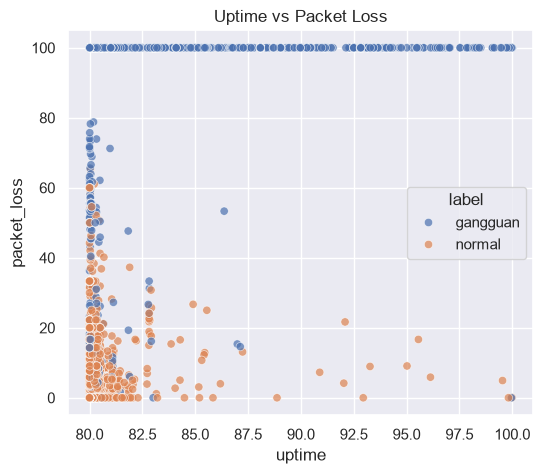

In [217]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=labeled_df,
    x="uptime",
    y="packet_loss",
    hue="label",
    alpha=0.7
)

plt.title("Uptime vs Packet Loss")
plt.show()
save_plot("scatter_uptime_packetloss.png")

Berdasarkan visualisasi scatter plot antara parameter uptime dan packet loss, terlihat bahwa sebagian besar data memiliki nilai uptime pada rentang 80% hingga 100%. Namun demikian, nilai `packet_loss` masih menunjukkan variasi yang cukup besar pada rentang uptime tersebut.

Titik data dengan label gangguan cenderung mendominasi area yang memiliki nilai `packet_loss` tinggi, terutama pada rentang 40% hingga 100%. Sebaliknya, data dengan label normal lebih banyak berada pada area dengan nilai packet loss rendah hingga menengah.

Selain itu, terdapat beberapa data dengan nilai uptime yang tinggi tetapi masih memiliki packet loss yang besar. Kondisi ini menunjukkan bahwa uptime tidak selalu menjadi indikator tunggal dalam menentukan kualitas jaringan, karena gangguan jaringan juga dapat dipengaruhi oleh parameter lain seperti `latency`, `bandwidth`, dan `packet_loss`.

Secara keseluruhan, visualisasi ini menunjukkan bahwa `packet_loss` memiliki pengaruh yang lebih kuat terhadap pembentukan label dibandingkan uptime. Hal ini juga sejalan dengan hasil feature importance yang menunjukkan bahwa packet loss merupakan salah satu fitur yang paling berkontribusi dalam proses klasifikasi gangguan jaringan.

# Modeling

Tahap Modeling dilakukan untuk membangun model klasifikasi yang mampu memprediksi kondisi jaringan berdasarkan parameter monitoring yang tersedia. Pada penelitian ini digunakan dua algoritma yaitu `Random Forest` dan `Naive Bayes`.

Sebelum proses pelatihan model dilakukan, proses hyperparameter tuning diterapkan untuk memperoleh konfigurasi parameter yang memberikan performa terbaik berdasarkan hasil cross validation.

### Label Encoder

In [218]:
features = [
    "bandwidth",
    "latency",
    "packet_loss",
    "uptime"
]
x = labeled_df[features]

y = labeled_df["label"]

le = LabelEncoder()

y_enc = le.fit_transform(y)


print(y.value_counts())

label
normal      1475
gangguan    1246
Name: count, dtype: int64


### Split training & test

In [219]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=42
)

### Scaler

In [220]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### Hyperparameter Tuning Random Forest

In [221]:
param_grid = {

    "n_estimators":[
        100,
        200,
        300
    ],

    "max_depth":[
        5,
        10,
        15
    ],

    "min_samples_split":[
        5,
        10,
        20
    ],

    "min_samples_leaf":[
        2,
        5,
        10
    ]
}

grid_rf = GridSearchCV(

    RandomForestClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring="f1_macro",

    n_jobs=-1

)

grid_rf.fit(
    x_train,
    y_train
)

rf = grid_rf.best_estimator_

print(
    grid_rf.best_params_
)

{'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 20, 'n_estimators': 200}


Grid Search digunakan untuk mencari kombinasi parameter terbaik pada algoritma `Random Forest` sehingga mampu menghasilkan performa yang optimal pada data pelatihan.

### Hasil Tabel Kombinasi Parameter

In [222]:
rf_tuning_results = pd.DataFrame(
    grid_rf.cv_results_
)

rf_tuning_results[
    [
        "mean_test_score",
        "std_test_score",
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf"
    ]
].sort_values(
    by="mean_test_score",
    ascending=False
).head(10)

,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf
61,0.951181,0.014997,200,15,20,2
71,0.950726,0.014574,300,15,20,5
28,0.950709,0.014441,200,10,5,2
33,0.950260,0.015779,100,10,20,2
43,0.950257,0.014212,200,10,20,5
70,0.950257,0.014212,200,15,20,5
34,0.950251,0.014824,200,10,20,2
72,0.949817,0.015240,100,15,5,10
78,0.949817,0.015240,100,15,20,10
75,0.949817,0.015240,100,15,10,10


Tabel berikut menampilkan kombinasi parameter terbaik berdasarkan nilai rata-rata F1-Score hasil Cross Validation. Kombinasi parameter dengan nilai F1-Score tertinggi dipilih sebagai model `Random Forest` terbaik yang akan digunakan pada tahap evaluasi.

### Visualisasi Hasil Tuning Random Forest

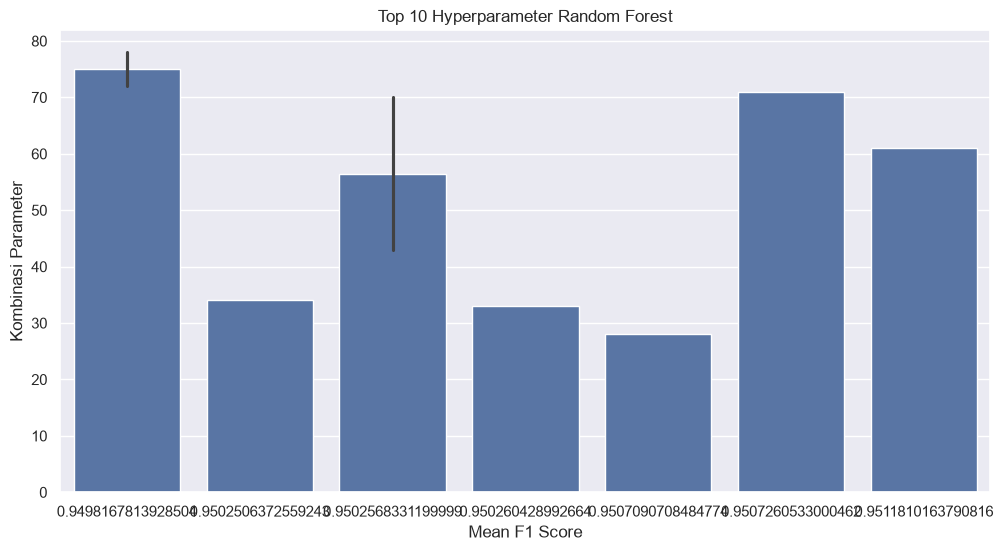

In [223]:
top10_rf = rf_tuning_results.sort_values(
    by="mean_test_score",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_rf,
    x="mean_test_score",
    y=top10_rf.index,
)

plt.xlabel("Mean F1 Score")
plt.ylabel("Kombinasi Parameter")
plt.title("Top 10 Hyperparameter Random Forest")

plt.show()

Berdasarkan grafik `Top 10 Hyperparameter Random Forest`, terlihat bahwa beberapa kombinasi parameter menghasilkan performa yang relatif mirip dengan nilai `Mean F1-Score` yang berada pada rentang sekitar `0.949` hingga `0.951`.

Perbedaan nilai performa antar kombinasi parameter terlihat sangat kecil. Hal ini menunjukkan bahwa algoritma `Random Forest` memiliki tingkat stabilitas yang baik karena perubahan parameter tidak menyebabkan perubahan performa yang signifikan.

Kombinasi parameter terbaik menghasilkan nilai `Mean F1-Score` sekitar `0.951`, yang merupakan nilai tertinggi dibandingkan kombinasi parameter lainnya. Hasil ini menunjukkan bahwa proses `GridSearchCV` berhasil menemukan konfigurasi parameter yang mampu meningkatkan kemampuan model dalam mengklasifikasikan kondisi jaringan.

Selain itu, selisih performa yang relatif kecil antar kombinasi parameter menunjukkan bahwa model tidak terlalu sensitif terhadap perubahan parameter tertentu. Kondisi ini mengindikasikan bahwa pola klasifikasi yang dipelajari oleh model cukup konsisten dan tidak bergantung pada satu konfigurasi parameter tertentu.

Secara keseluruhan, hasil `Hyperparameter Tuning` menunjukkan bahwa proses optimasi parameter berhasil menghasilkan model `Random Forest` yang lebih optimal dengan performa klasifikasi yang stabil dan mampu memberikan nilai `F1-Score` yang tinggi pada proses validasi silang (`Cross Validation`).

### Hyperparameter Tuning Naive Bayes

In [224]:
param_grid_nb = {

    "var_smoothing": [
        1e-12,
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7,
        1e-6,
        1e-5,
        1e-4,
        1e-3
    ]

}

grid_nb = GridSearchCV(

    estimator=GaussianNB(),

    param_grid=param_grid_nb,

    cv=5,

    scoring="f1_macro",

    n_jobs=-1

)

grid_nb.fit(
    x_train,
    y_train
)

nb = grid_nb.best_estimator_

print("Best Parameter:")
print(grid_nb.best_params_)

print("Best Score:")
print(grid_nb.best_score_)

Best Parameter:
{'var_smoothing': 1e-12}
Best Score:
0.9399490929588212


Proses hyperparameter tuning dilakukan menggunakan Grid Search Cross Validation untuk mencari nilai parameter `var_smoothing` terbaik pada algoritma Gaussian Naive Bayes.

Parameter `var_smoothing` digunakan untuk menambahkan nilai stabilisasi pada varians setiap fitur sehingga dapat mengurangi risiko overfitting dan meningkatkan kemampuan generalisasi model terhadap data yang belum pernah dilihat sebelumnya.

Nilai parameter terbaik dipilih berdasarkan skor F1-Macro tertinggi pada proses validasi silang (Cross Validation).

### Visualisasi Hasil Tuning Naive Bayes

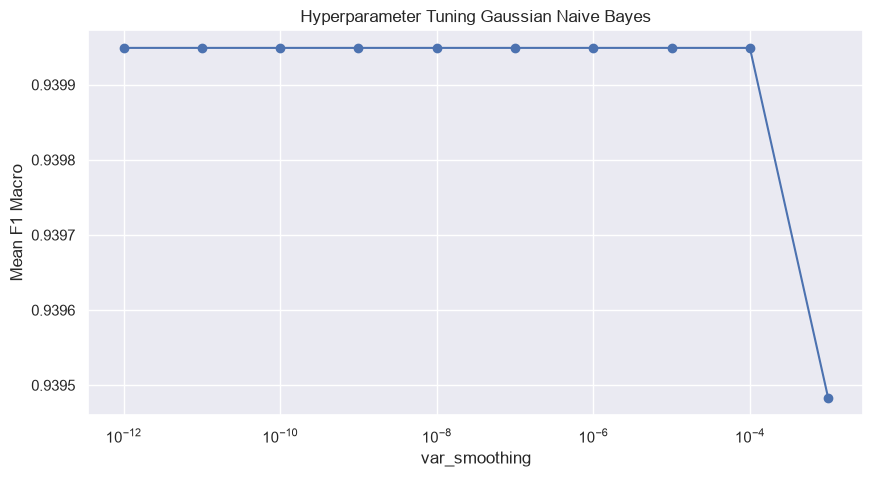

In [225]:
cv_nb = pd.DataFrame(
    grid_nb.cv_results_
)

plt.figure(figsize=(10,5))

plt.semilogx(
    cv_nb["param_var_smoothing"].astype(float),
    cv_nb["mean_test_score"],
    marker="o"
)

plt.xlabel("var_smoothing")

plt.ylabel("Mean F1 Macro")

plt.title(
    "Hyperparameter Tuning Gaussian Naive Bayes"
)

plt.grid(True)

plt.show()

Berdasarkan grafik `Hyperparameter Tuning Gaussian Naive Bayes`, terlihat bahwa perubahan nilai parameter `var_smoothing` dari `1e-12` hingga `1e-4` tidak memberikan pengaruh yang signifikan terhadap performa model. Hal ini ditunjukkan oleh nilai `Mean F1 Macro` yang relatif konstan pada seluruh rentang parameter tersebut.

Nilai `Mean F1 Macro` tertinggi diperoleh pada `var_smoothing = 1e-12` dengan performa sekitar `0.9399`. Namun demikian, perbedaan performa antar kombinasi parameter sangat kecil sehingga hampir seluruh nilai `var_smoothing` menghasilkan kualitas klasifikasi yang serupa.

Pada nilai `var_smoothing = 1e-3`, terlihat adanya sedikit penurunan nilai `Mean F1 Macro`. Penurunan ini menunjukkan bahwa proses smoothing yang terlalu besar dapat mengurangi kemampuan model dalam menangkap distribusi asli data sehingga performa klasifikasi menjadi sedikit lebih rendah.

Secara keseluruhan, hasil tuning menunjukkan bahwa algoritma `Gaussian Naive Bayes` memiliki performa yang cukup stabil terhadap perubahan parameter `var_smoothing`. Hal ini mengindikasikan bahwa model tidak terlalu sensitif terhadap proses tuning dan mampu menghasilkan performa yang konsisten pada berbagai konfigurasi parameter.

Berdasarkan hasil `GridSearchCV`, nilai parameter terbaik diperoleh pada `var_smoothing = 1e-12`, sehingga parameter tersebut digunakan pada proses pembentukan model akhir.

### Implementasi Metode Model Algoritma Random Forest

Algoritma `Random Forest` bekerja dengan membangun sejumlah pohon keputusan (*Decision Tree*) dan menggabungkan hasil prediksi dari seluruh pohon menggunakan mekanisme *majority voting*.

Persamaan prediksi pada Random Forest dapat dituliskan sebagai berikut:

$$
\hat{y} = \text{mode}
\left(
h_1(x),
h_2(x),
h_3(x),
\ldots,
h_n(x)
\right)
$$

Keterangan:

- $\hat{y}$ : hasil prediksi akhir
- $h_i(x)$ : prediksi dari pohon keputusan ke-$i$
- $n$ : jumlah pohon (*n\_estimators*)
- $\text{mode}(\cdot)$ : kelas yang paling banyak dipilih oleh seluruh pohon

Pada penelitian ini, proses pencarian parameter terbaik dilakukan menggunakan metode `GridSearchCV` dengan kombinasi parameter `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, dan `max_features`.

Untuk menentukan pemisahan node terbaik pada setiap pohon keputusan digunakan nilai Gini Impurity yang dirumuskan sebagai berikut:

$$
Gini(D)
=
1
-
\sum_{i=1}^{c}
p_i^2
$$

Keterangan:

- $Gini(D)$ : nilai impurity pada node
- $p_i$ : proporsi kelas ke-$i$
- $c$ : jumlah kelas

Semakin kecil nilai Gini Impurity maka semakin baik kualitas pemisahan data pada node tersebut.

In [226]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, 7],
    "min_samples_split": [10, 20, 30],
    "min_samples_leaf": [5, 10, 15],
    "max_features": ["sqrt"]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1
)

grid_rf.fit(x_train, y_train)

rf = grid_rf.best_estimator_

print("Random Forest:")
print(grid_rf.best_params_)

Random Forest:
{'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 30, 'n_estimators': 100}


### Implementasi Metode Model Algoritma Naive Bayes

Algoritma `Gaussian Naive Bayes` menggunakan Teorema Bayes untuk menghitung probabilitas suatu kelas berdasarkan fitur yang dimiliki data.

Persamaan Teorema Bayes adalah:

$$
P(C|X)
=
\frac{
P(X|C)
\cdot
P(C)
}
{
P(X)
}
$$

Keterangan:

- $P(C|X)$ : probabilitas kelas setelah melihat data
- $P(X|C)$ : probabilitas data pada kelas tertentu
- $P(C)$ : probabilitas awal kelas (*prior probability*)
- $P(X)$ : probabilitas data

Keputusan klasifikasi diperoleh dengan memilih kelas yang memiliki probabilitas posterior terbesar:

$$
\hat{C}
=
\arg\max_C
P(C|X)
$$

dengan:

- $\hat{C}$ : kelas hasil prediksi
- $\arg\max$ : nilai probabilitas terbesar

Pada penelitian ini digunakan algoritma `Gaussian Naive Bayes` sehingga setiap fitur diasumsikan mengikuti distribusi normal (Gaussian) yang dirumuskan sebagai berikut:

$$
P(x_i|C)
=
\frac
{1}
{\sqrt{2\pi\sigma_C^2}}
\exp
\left(
-\frac
{
(x_i-\mu_C)^2
}
{
2\sigma_C^2
}
\right)
$$

Keterangan:

- $x_i$ : nilai fitur ke-$i$
- $\mu_C$ : rata-rata fitur pada kelas $C$
- $\sigma_C^2$ : varians fitur pada kelas $C$
- $\exp$ : fungsi eksponensial

Nilai probabilitas setiap fitur kemudian dikombinasikan untuk menentukan kelas dengan probabilitas tertinggi.

In [227]:
nb = grid_nb.best_estimator_

nb.fit(x_train, y_train)

,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-12
,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[ 996.,1180.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.46,0.54]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-12
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 4)","[[ 0.08, 0.22, 0.96, 0.35], [-0.07,-0.19,-0.81,-0.3 ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 4)","[[1.26,1.46,0.42,1.76], [0.77,0.53,0.05,0.16]]"


Model Random Forest dioptimasi menggunakan GridSearchCV untuk mencari kombinasi parameter terbaik berdasarkan nilai F1-score.

Sementara itu, Naive Bayes digunakan sebagai pembanding karena memiliki karakteristik model probabilistik yang ringan dan cepat dalam proses komputasi.

# Evaluasi Model

Tahap Evaluation dilakukan untuk mengukur performa model dalam mengklasifikasikan kondisi jaringan. Evaluasi dilakukan menggunakan berbagai metrik seperti Accuracy, Precision, Recall, F1-Score, ROC-AUC, dan Precision Recall Curve.

Selain itu dilakukan analisis confusion matrix, learning curve, serta feature importance untuk memahami perilaku model secara lebih mendalam.

In [228]:
y_pred_rf = rf.predict(x_test)
y_pred_nb = nb.predict(x_test)

### Cross Validasi

In [229]:
rf_cv = cross_val_score(
    rf,
    x_train,
    y_train,
    cv=5,
    scoring="f1"
)

nb_cv = cross_val_score(
    nb,
    x_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("RF CV Mean:", rf_cv.mean())
print("NB CV Mean:", nb_cv.mean())

RF CV Mean: 0.9550850760849061
NB CV Mean: 0.9467038731342738


### Hasil Nilai Klasifikasi

In [230]:
print("=== RANDOM FOREST ===")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=le.classes_
    )
)

print("=== NAIVE BAYES ===")
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=le.classes_
    )
)

=== RANDOM FOREST ===
              precision    recall  f1-score   support

    gangguan       0.97      0.94      0.95       250
      normal       0.95      0.98      0.96       295

    accuracy                           0.96       545
   macro avg       0.96      0.96      0.96       545
weighted avg       0.96      0.96      0.96       545

=== NAIVE BAYES ===
              precision    recall  f1-score   support

    gangguan       0.97      0.91      0.94       250
      normal       0.93      0.97      0.95       295

    accuracy                           0.94       545
   macro avg       0.95      0.94      0.94       545
weighted avg       0.95      0.94      0.94       545



Evaluasi dilakukan menggunakan beberapa metrik seperti accuracy, precision, recall, dan F1-score. sebagai model klasifikasi

Dalam konteks monitoring jaringan, recall menjadi salah satu metrik yang penting karena model diharapkan mampu mendeteksi kondisi gangguan sebanyak mungkin untuk meminimalkan risiko gangguan yang tidak terdeteksi.

### Confusion Matrix 


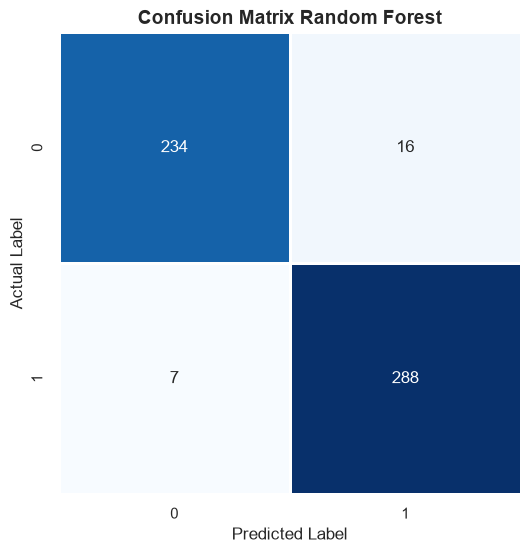

In [231]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=1,
    square=True
)

plt.title(
    "Confusion Matrix Random Forest",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.show()

Berdasarkan hasil `Confusion Matrix`, algoritma `Random Forest` menunjukkan kemampuan klasifikasi yang sangat baik dalam membedakan kondisi jaringan `normal` dan `gangguan`.

Model berhasil mengklasifikasikan sebanyak `234` data `normal` dengan benar (`True Negative`) dan `288` data `gangguan` dengan benar (`True Positive`). Hasil ini menunjukkan bahwa sebagian besar data pengujian berhasil diprediksi sesuai dengan kondisi sebenarnya.

Selain itu, terdapat `16` data `normal` yang salah diklasifikasikan sebagai `gangguan` (`False Positive`). Kesalahan ini menunjukkan bahwa model sesekali memberikan peringatan gangguan pada kondisi jaringan yang sebenarnya masih normal.

Sementara itu, terdapat `7` data `gangguan` yang salah diklasifikasikan sebagai `normal` (`False Negative`). Jumlah kesalahan ini relatif kecil dan menunjukkan bahwa model mampu mendeteksi sebagian besar kondisi gangguan yang terjadi pada jaringan.

Jika dihitung berdasarkan total data pengujian sebanyak `545` data, model berhasil melakukan klasifikasi yang benar pada `522` data. Hasil tersebut menunjukkan bahwa algoritma `Random Forest` memiliki tingkat akurasi yang sangat tinggi dalam proses klasifikasi kondisi jaringan.

Secara keseluruhan, hasil `Confusion Matrix` menunjukkan bahwa algoritma `Random Forest` memiliki performa yang sangat baik dalam mendeteksi kondisi jaringan `normal` maupun `gangguan`, dengan jumlah kesalahan klasifikasi yang relatif rendah pada kedua kelas.

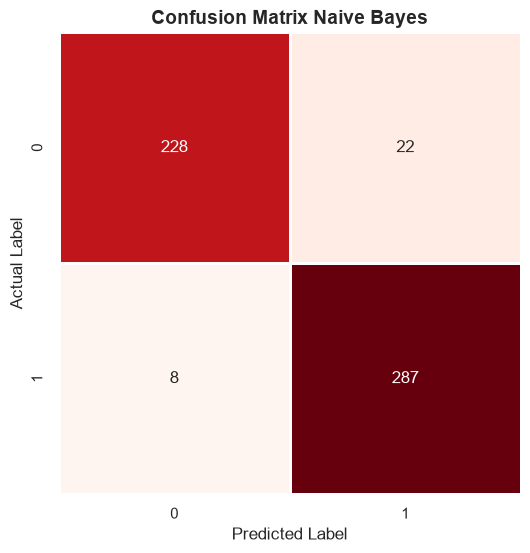

In [232]:
cm = confusion_matrix(
    y_test,
    y_pred_nb
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    cbar=False,
    linewidths=1,
    square=True
)

plt.title(
    "Confusion Matrix Naive Bayes",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.show()

Berdasarkan hasil `Confusion Matrix`, algoritma `Naive Bayes` menunjukkan kemampuan klasifikasi yang sangat baik dalam membedakan kondisi jaringan `normal` dan `gangguan`.

Model berhasil mengklasifikasikan sebanyak `228` data `normal` dengan benar (`True Negative`) dan `287` data `gangguan` dengan benar (`True Positive`). Hasil ini menunjukkan bahwa sebagian besar data berhasil dikenali sesuai dengan kondisi sebenarnya.

Selain itu, terdapat `22` data `normal` yang salah diklasifikasikan sebagai `gangguan` (`False Positive`). Kesalahan ini menunjukkan bahwa model sesekali memberikan peringatan gangguan meskipun kondisi jaringan sebenarnya masih normal.

Sementara itu, terdapat `8` data `gangguan` yang salah diklasifikasikan sebagai `normal` (`False Negative`). Jumlah kesalahan ini relatif kecil dan menunjukkan bahwa model mampu mendeteksi sebagian besar kondisi gangguan yang terjadi pada jaringan.

Jika dihitung berdasarkan total data pengujian sebanyak `545` data, model berhasil melakukan klasifikasi yang benar pada `515` data. Hal ini menunjukkan bahwa algoritma `Naive Bayes` memiliki tingkat akurasi yang tinggi dalam proses klasifikasi kondisi jaringan.

Secara keseluruhan, hasil `Confusion Matrix` menunjukkan bahwa algoritma `Naive Bayes` memiliki performa yang baik dalam mendeteksi gangguan jaringan. Namun demikian, jumlah `False Positive` yang sedikit lebih tinggi dibandingkan `Random Forest` menunjukkan bahwa model ini cenderung lebih sering memberikan prediksi gangguan pada kondisi yang sebenarnya masih normal.

Confusion matrix membantu memperlihatkan jenis kesalahan prediksi yang dilakukan model.

Kesalahan yang paling perlu diperhatikan adalah ketika kondisi gangguan diprediksi sebagai normal karena kondisi tersebut dapat menyebabkan gangguan jaringan tidak terdeteksi lebih awal.

### ROC Curve

<Figure size 600x500 with 0 Axes>

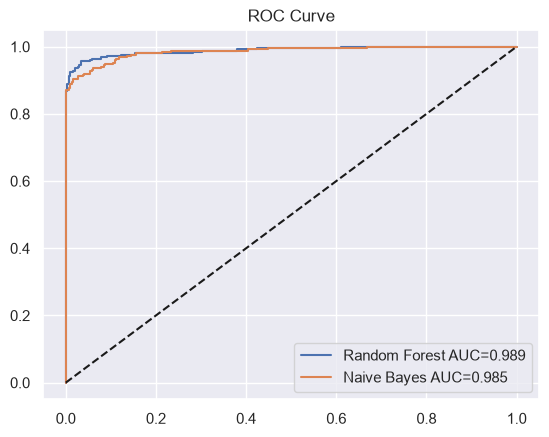

In [233]:
# ROC Curve
gangguan_index = int(le.transform(["gangguan"])[0])

rf_proba = rf.predict_proba(x_test)[:, gangguan_index]
nb_proba = nb.predict_proba(x_test)[:, gangguan_index]

y_test_bin = (
    y_test == gangguan_index
).astype(int)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test_bin,
    rf_proba
)

fpr_nb, tpr_nb, _ = roc_curve(
    y_test_bin,
    nb_proba
)

roc_auc_rf = auc(fpr_rf, tpr_rf)
roc_auc_nb = auc(fpr_nb, tpr_nb)

plt.figure(figsize=(6,5))
plt.show()
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest AUC={roc_auc_rf:.3f}"
)

plt.plot(
    fpr_nb,
    tpr_nb,
    label=f"Naive Bayes AUC={roc_auc_nb:.3f}"
)

plt.plot([0,1],[0,1],"k--")

plt.legend()

plt.title("ROC Curve")
plt.show()
save_plot("roc_curve.png")

Berdasarkan grafik `ROC Curve`, algoritma `Random Forest` dan `Naive Bayes` menunjukkan kemampuan klasifikasi yang sangat baik dalam membedakan kondisi jaringan `normal` dan `gangguan`. Hal ini terlihat dari posisi kedua kurva yang berada jauh di atas garis diagonal (*random classifier*) dan mendekati sudut kiri atas grafik.

Algoritma `Random Forest` memperoleh nilai `AUC = 0.989`, sedangkan algoritma `Naive Bayes` memperoleh nilai `AUC = 0.985`. Nilai `AUC` yang mendekati `1.0` menunjukkan bahwa kedua model memiliki kemampuan diskriminasi yang sangat tinggi dalam membedakan dua kelas yang digunakan pada penelitian ini.

Kurva `Random Forest` terlihat sedikit lebih tinggi dibandingkan kurva `Naive Bayes` pada sebagian besar area grafik. Hal ini menunjukkan bahwa `Random Forest` memiliki kemampuan yang lebih baik dalam mengidentifikasi data gangguan maupun data normal secara konsisten pada berbagai nilai threshold.

Selain itu, kedua model mampu mempertahankan nilai `True Positive Rate (TPR)` yang tinggi dengan nilai `False Positive Rate (FPR)` yang relatif rendah. Kondisi tersebut menunjukkan bahwa model dapat mendeteksi sebagian besar gangguan jaringan tanpa menghasilkan terlalu banyak kesalahan klasifikasi pada kondisi normal.

Berdasarkan hasil evaluasi `ROC Curve`, kedua model termasuk dalam kategori `Excellent Classification` karena memiliki nilai `AUC > 0.90`. Namun demikian, algoritma `Random Forest` tetap menjadi model terbaik karena menghasilkan nilai `AUC` yang lebih tinggi dibandingkan `Naive Bayes`.

ROC Curve memperlihatkan kemampuan model dalam membedakan antara kondisi normal dan gangguan pada berbagai threshold probabilitas.

Semakin mendekati sudut kiri atas, semakin baik kemampuan model dalam melakukan klasifikasi.

### Precision Recall Curve

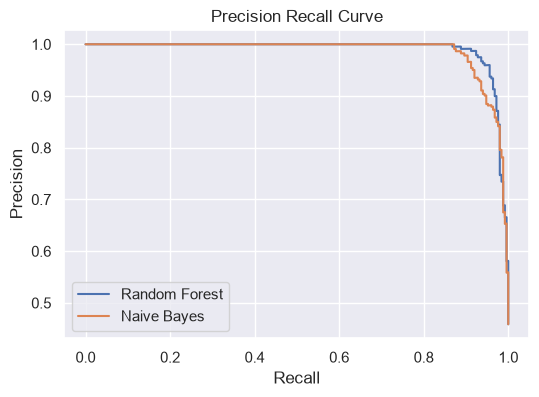

In [234]:
# Precision Recall Curve
prec_rf, rec_rf, _ = precision_recall_curve(
    y_test_bin,
    rf_proba
)

prec_nb, rec_nb, _ = precision_recall_curve(
    y_test_bin,
    nb_proba
)

plt.figure(figsize=(6,4))

plt.plot(
    rec_rf,
    prec_rf,
    label="Random Forest"
)

plt.plot(
    rec_nb,
    prec_nb,
    label="Naive Bayes"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.title("Precision Recall Curve")
plt.show()
save_plot("pr_curve.png")

Berdasarkan grafik `Precision Recall Curve`, algoritma `Random Forest` dan `Naive Bayes` menunjukkan performa klasifikasi yang sangat baik dalam membedakan kondisi jaringan `normal` dan `gangguan`. Hal ini ditunjukkan oleh kurva kedua model yang berada pada area bagian atas grafik, dengan nilai `Precision` yang tetap tinggi meskipun nilai `Recall` meningkat.

Pada sebagian besar rentang `Recall`, kedua model mampu mempertahankan nilai `Precision` mendekati `1.0`. Kondisi ini menunjukkan bahwa sebagian besar prediksi yang dihasilkan model merupakan prediksi yang benar dan hanya menghasilkan sedikit kesalahan klasifikasi.

Ketika nilai `Recall` mendekati `1.0`, terlihat adanya penurunan nilai `Precision` pada kedua model. Fenomena ini merupakan kondisi yang umum terjadi karena model berusaha mendeteksi lebih banyak data positif sehingga risiko munculnya prediksi yang salah menjadi lebih besar.

Jika dibandingkan secara visual, kurva `Random Forest` berada sedikit di atas kurva `Naive Bayes` pada sebagian besar area grafik. Hal ini menunjukkan bahwa `Random Forest` memiliki keseimbangan yang lebih baik antara kemampuan mendeteksi gangguan (`Recall`) dan ketepatan prediksi (`Precision`) dibandingkan `Naive Bayes`.

Secara keseluruhan, hasil `Precision Recall Curve` menunjukkan bahwa kedua algoritma memiliki kemampuan klasifikasi yang sangat baik. Namun demikian, algoritma `Random Forest` memberikan performa yang sedikit lebih unggul karena mampu mempertahankan nilai `Precision` yang lebih tinggi pada tingkat `Recall` yang sama.

Precision Recall Curve digunakan untuk melihat keseimbangan antara kemampuan model dalam mendeteksi gangguan dan ketepatan prediksi yang dihasilkan.

Visualisasi ini menjadi penting terutama ketika distribusi kelas tidak sepenuhnya seimbang.

### Tabel Perbandingan Model

In [235]:
metrics_df = pd.DataFrame({
    "Model": ["Random Forest", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_nb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_nb)
    ]
})

metrics_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.957798,0.947368,0.976271,0.961603
1,Naive Bayes,0.944954,0.928803,0.972881,0.950331


### Menyimpan Hasil Klasifikasi Ke Dalam JSON

In [236]:
# Export Metrics Summary Ke JSON

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

metrics_summary = {
    "rf": {
        "accuracy": float(rf_accuracy),
        "precision": float(rf_precision),
        "recall": float(rf_recall),
        "f1": float(rf_f1),
        "roc_auc": float(roc_auc_rf),
        "pr_auc": float(
            auc(rec_rf, prec_rf)
        )
    },

    "nb": {
        "accuracy": float(nb_accuracy),
        "precision": float(nb_precision),
        "recall": float(nb_recall),
        "f1": float(nb_f1),
        "roc_auc": float(roc_auc_nb),
        "pr_auc": float(
            auc(rec_nb, prec_nb)
        )
    },

    "label_classes": list(le.classes_),

    "feature_names": [
        "bandwidth",
        "latency",
        "packet_loss",
        "uptime"
    ]
}

with open(
    os.path.join(BASE_DIR, "metrics_summary.json"),
    "w"
) as f:

    json.dump(
        metrics_summary,
        f,
        indent=4
    )

print("metrics_summary.json berhasil diperbarui")

metrics_summary.json berhasil diperbarui


### Grafik Bar Perbandingan Kedua Algoritma

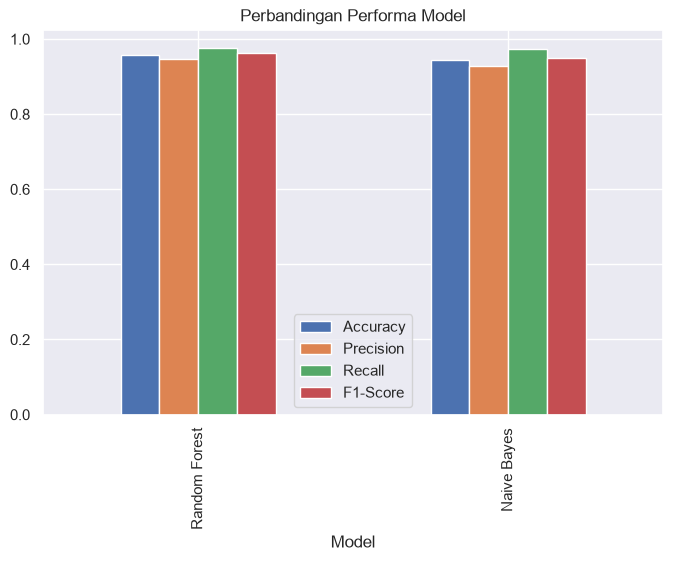

In [237]:
metrics_df.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Perbandingan Performa Model")
plt.show()
save_plot("model_comparison.png")

Hasil evaluasi menunjukkan bahwa algoritma `Random Forest` memiliki performa yang sedikit lebih unggul dibandingkan `Naive Bayes` pada hampir seluruh metrik evaluasi. Perbedaan terbesar terlihat pada metrik `Precision`, di mana Random Forest menghasilkan nilai yang lebih tinggi dibandingkan Naive Bayes.

Nilai precision yang lebih tinggi menunjukkan bahwa Random Forest lebih mampu mengurangi kesalahan prediksi positif (*False Positive*) dibandingkan Naive Bayes. Dengan kata lain, ketika model memprediksi adanya gangguan jaringan, kemungkinan prediksi tersebut benar lebih tinggi pada Random Forest.

Selain itu, nilai `F1-Score` Random Forest juga sedikit lebih tinggi dibandingkan Naive Bayes. Hal ini menunjukkan bahwa keseimbangan antara precision dan recall pada Random Forest lebih baik dibandingkan model Naive Bayes.

Berdasarkan hasil evaluasi menggunakan metrik `Accuracy`, `Precision`, `Recall`, dan `F1-Score`, kedua algoritma menunjukkan performa yang sangat baik dalam mengklasifikasikan kondisi jaringan.

Namun demikian, algoritma `Random Forest` memberikan performa yang lebih unggul dibandingkan `Naive Bayes` dengan nilai accuracy, precision, dan F1-score yang lebih tinggi serta jumlah kesalahan klasifikasi yang lebih rendah.

Oleh karena itu, pada penelitian ini algoritma `Random Forest` dapat dianggap sebagai model terbaik untuk melakukan prediksi gangguan jaringan berdasarkan parameter `bandwidth`, `latency`, `packet_loss`, dan `uptime`.

Berdasarkan seluruh hasil pengujian, analisis learning curve, confusion matrix, ROC Curve, Precision-Recall Curve, serta evaluasi metrik klasifikasi, algoritma `Random Forest` terbukti memiliki kemampuan generalisasi yang lebih baik dibandingkan `Naive Bayes` dalam memprediksi kondisi gangguan jaringan. Oleh karena itu, model Random Forest dipilih sebagai model utama yang diimplementasikan pada sistem prediksi gangguan jaringan berbasis Dashboard web app.

### Learning Curve

In [238]:
from pathlib import Path

RANDOM_STATE = 42

def generate_learning_curve(estimator, X_vec, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    Menghasilkan data learning curve.
    Return:
        train_sizes_abs, train_mean, train_std, val_mean, val_std, gap, val_final
    """
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator,
        X_vec,
        y,
        train_sizes=train_sizes,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    gap = train_mean[-1] - val_mean[-1]
    val_final = val_mean[-1]

    return train_sizes_abs, train_mean, train_std, val_mean, val_std, gap, val_final


def diagnosa_fit(gap, val_final):
    """
    Diagnosis sederhana berdasarkan gap dan validation score.
    """
    if gap > 0.20:
        return "OVERFITTING", "#e74c3c"
    elif val_final < 0.45 and gap < 0.05:
        return "UNDERFITTING", "#e67e22"
    elif gap <= 0.10 and val_final >= 0.60:
        return "GOOD FIT", "#27ae60"
    else:
        return "SLIGHT OVERFIT", "#f39c12"


def plot_single_learning_curve(estimator, X_vec, y, nama_model, filename):
    """
    Plot learning curve satu model dalam satu figure tersendiri.
    Output PNG disimpan ke folder img/.
    """
    print(f"Menghitung learning curve: {nama_model}...")

    ts, tm, ts_std, vm, vs_std, gap, val_f = generate_learning_curve(
        estimator, X_vec, y
    )
    diagnosis, diag_color = diagnosa_fit(gap, val_f)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(
        ts, tm,
        color="steelblue",
        marker="o",
        markersize=5,
        linewidth=2,
        label="Training Score"
    )
    ax.plot(
        ts, vm,
        color="tomato",
        marker="s",
        markersize=5,
        linewidth=2,
        label="Validation Score (CV-5)"
    )

    ax.fill_between(ts, tm - ts_std, tm + ts_std, alpha=0.12, color="steelblue")
    ax.fill_between(ts, vm - vs_std, vm + vs_std, alpha=0.12, color="tomato")

    ax.axhline(
        y=0.80,
        color="#27ae60",
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
        label="Target 80%"
    )

    ax.annotate(
        f"Gap = {gap:.3f}",
        xy=(ts[-1], (tm[-1] + vm[-1]) / 2),
        xytext=(ts[-3], (tm[-1] + vm[-1]) / 2 + 0.05),
        fontsize=9,
        color="gray",
        arrowprops=dict(arrowstyle="->", color="gray", lw=1)
    )

    ax.set_title(
        f"{nama_model}\nGap={gap:.3f} | Val F1-Mac={val_f:.3f} | [{diagnosis}]",
        fontsize=12,
        fontweight="bold",
        color=diag_color,
        pad=12
    )
    ax.set_xlabel("Jumlah Sampel Training", fontsize=11)
    ax.set_ylabel("F1-Score Macro", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    Path("static").mkdir(exist_ok=True)
    save_path = Path("static") / filename

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Disimpan: {filename}")
    print(f"Diagnosis: {diagnosis} | Val={val_f:.4f} | Gap={gap:.4f}\n")

    return gap, val_f, diagnosis

Learning curve digunakan untuk memahami bagaimana model belajar terhadap data training dan bagaimana kemampuan generalisasinya terhadap data validasi.

Apabila jarak antara kurva training dan validation terlalu jauh, maka model berpotensi mengalami overfitting. Sebaliknya, apabila kedua kurva sama-sama rendah, maka model dapat mengalami underfitting.

Visualisasi ini membantu memastikan bahwa model tidak hanya menghafal data training, tetapi juga mampu memahami pola yang lebih umum pada data jaringan.

Menghitung learning curve: Random Forest...


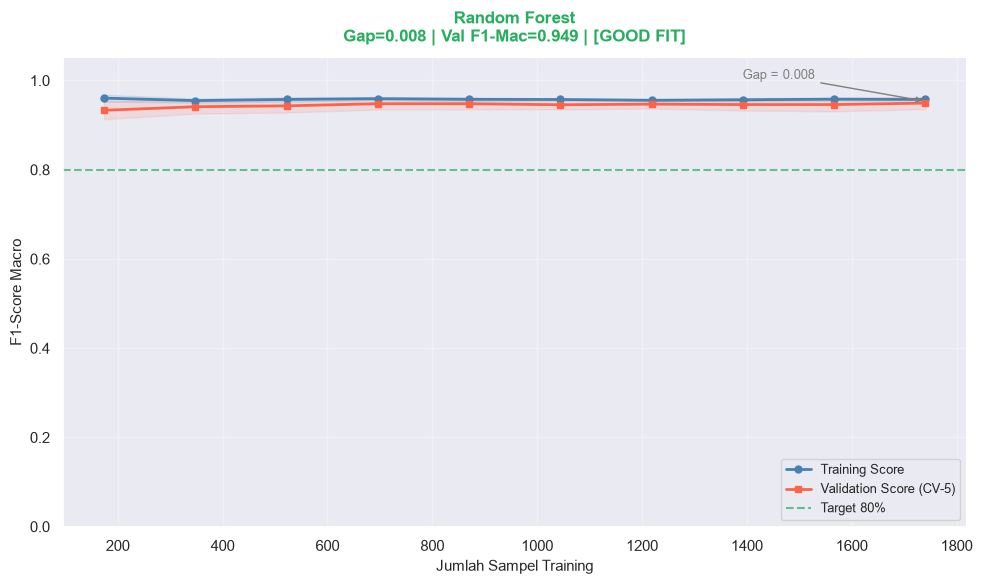

Disimpan: lc_random_forest.png
Diagnosis: GOOD FIT | Val=0.9493 | Gap=0.0083



{'Random Forest': (np.float64(0.008277118219858992),
  np.float64(0.9493293292566314),
  'GOOD FIT')}

In [239]:
results = {}

results["Random Forest"] = plot_single_learning_curve(
    rf,
    x_train,
    y_train,
    "Random Forest",
    "lc_random_forest.png"
)

results

Berdasarkan grafik *Learning Curve*, algoritma `Random Forest` menunjukkan performa yang sangat stabil selama proses pembelajaran. Kurva `Training Score` dan `Validation Score` berada pada rentang nilai yang tinggi serta memiliki jarak yang sangat kecil.

Nilai `Training F1-Score Macro` pada akhir proses mencapai sekitar `0.957`, sedangkan `Validation F1-Score Macro` mencapai sekitar `0.949`. Selisih kedua kurva atau `Gap` hanya sebesar `0.008`, yang menunjukkan bahwa model tidak mengalami overfitting maupun underfitting secara signifikan.

Selain itu, seluruh nilai `Validation Score` berada di atas target performa yang ditetapkan yaitu `0.80`. Hal ini menunjukkan bahwa model mampu mempertahankan performa yang baik ketika dihadapkan pada data yang belum pernah dilihat sebelumnya.

Pola kurva yang relatif sejajar dan stabil mengindikasikan bahwa algoritma `Random Forest` memiliki kemampuan generalisasi yang baik terhadap data gangguan jaringan. Dengan nilai `Gap = 0.008` dan `Validation F1-Score Macro = 0.949`, model dapat dikategorikan sebagai `GOOD FIT`.

Berdasarkan hasil tersebut dapat disimpulkan bahwa model `Random Forest` mampu mempelajari pola hubungan antara parameter `bandwidth`, `latency`, `packet_loss`, dan `uptime` secara efektif sehingga layak digunakan untuk proses klasifikasi kondisi jaringan.

Menghitung learning curve: Naive Bayes...


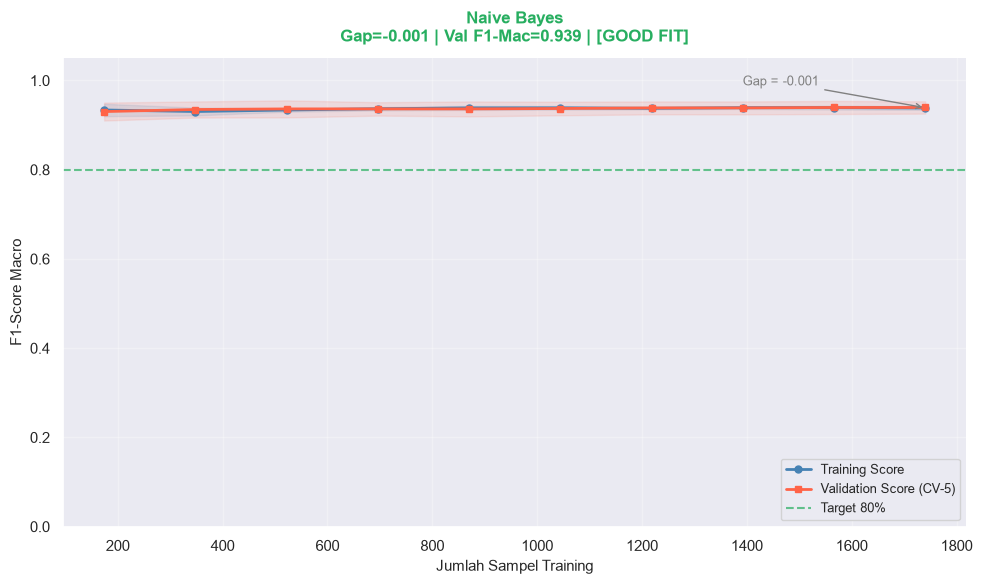

Disimpan: lc_naive_bayes.png
Diagnosis: GOOD FIT | Val=0.9395 | Gap=-0.0011



{'Random Forest': (np.float64(0.008277118219858992),
  np.float64(0.9493293292566314),
  'GOOD FIT'),
 'Naive Bayes': (np.float64(-0.001133889231870966),
  np.float64(0.939489791628563),
  'GOOD FIT')}

In [240]:
results["Naive Bayes"] = plot_single_learning_curve(
    nb,
    x_train,
    y_train,
    "Naive Bayes",
    "lc_naive_bayes.png"
)

results

Berdasarkan grafik *Learning Curve*, algoritma `Naive Bayes` menunjukkan performa klasifikasi yang sangat stabil pada seluruh ukuran data training. Kurva `Training Score` dan `Validation Score` berada pada rentang nilai yang hampir sama dengan selisih yang sangat kecil.

Nilai `Training F1-Score Macro` pada akhir proses pembelajaran mencapai sekitar `0.938`, sedangkan nilai `Validation F1-Score Macro` mencapai sekitar `0.939`. Selisih kedua kurva menghasilkan `Gap = -0.001`, yang menunjukkan bahwa performa model pada data validasi sedikit lebih tinggi dibandingkan data training. Kondisi ini masih dianggap normal dan sering terjadi akibat variasi pembagian data selama proses *cross validation*.

Selain itu, seluruh nilai `Validation Score` berada jauh di atas target performa yang ditetapkan yaitu `0.80`. Hal ini menunjukkan bahwa model memiliki kemampuan yang baik dalam menggeneralisasi pola yang terdapat pada data gangguan jaringan.

Kurva yang relatif sejajar dan tidak menunjukkan perbedaan yang signifikan mengindikasikan bahwa model `Naive Bayes` tidak mengalami gejala `overfitting` maupun `underfitting`. Dengan nilai `Gap = -0.001` dan `Validation F1-Score Macro = 0.939`, model dapat dikategorikan sebagai `GOOD FIT`.

Secara keseluruhan, algoritma `Naive Bayes` mampu mempelajari hubungan antara parameter `bandwidth`, `latency`, `packet_loss`, dan `uptime` dengan baik. Meskipun performanya sedikit berada di bawah algoritma `Random Forest`, model ini tetap menunjukkan kemampuan klasifikasi yang sangat baik dalam membedakan kondisi jaringan `normal` dan `gangguan`.

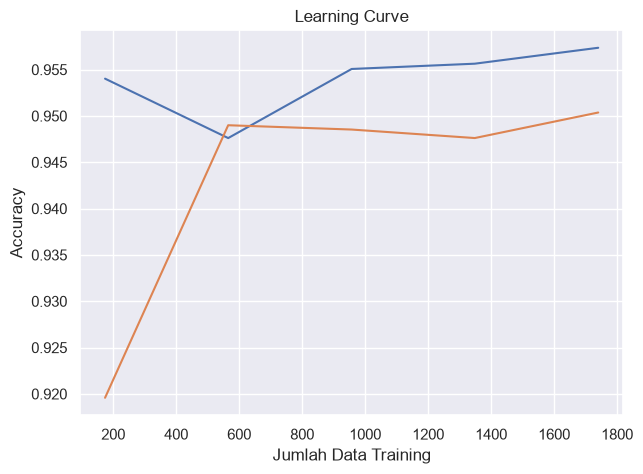

In [241]:
train_sizes, train_scores, val_scores = learning_curve(
    rf,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))

plt.plot(
    train_sizes,
    train_mean,
    label="Training Score"
)

plt.plot(
    train_sizes,
    val_mean,
    label="Validation Score"
)

plt.xlabel("Jumlah Data Training")
plt.ylabel("Accuracy")

plt.title("Learning Curve")
plt.show()
plt.legend()

save_plot("learning_curve.png")

Berdasarkan grafik *Learning Curve*, performa model menunjukkan pola pembelajaran yang stabil seiring bertambahnya jumlah data training. Nilai `Training Accuracy` dan `Validation Accuracy` sama-sama mengalami peningkatan dan cenderung konvergen pada akhir proses pembelajaran.

Pada jumlah data training yang lebih sedikit, terlihat adanya selisih yang cukup besar antara kurva training dan validation. Namun seiring bertambahnya jumlah data, kedua kurva semakin mendekat dan menunjukkan pola yang relatif stabil. Kondisi ini menunjukkan bahwa model mampu mempelajari pola data dengan baik tanpa mengalami overfitting yang signifikan.

Pada akhir proses pembelajaran, model memperoleh nilai `Training Accuracy` sekitar `95,7%`, sedangkan `Validation Accuracy` mencapai sekitar `95,0%`. Selisih kedua nilai tersebut hanya sekitar `0,7%`, sehingga menunjukkan kemampuan generalisasi yang baik terhadap data yang belum pernah dilihat sebelumnya.

Selain itu, kurva validasi tidak mengalami penurunan yang signifikan ketika jumlah data bertambah. Hal ini menunjukkan bahwa model mampu mempertahankan performanya secara konsisten pada berbagai ukuran data training.

Berdasarkan hasil tersebut, model dapat dikategorikan sebagai `GOOD FIT` karena memiliki performa validasi yang tinggi serta nilai gap yang relatif kecil antara data training dan data validation.

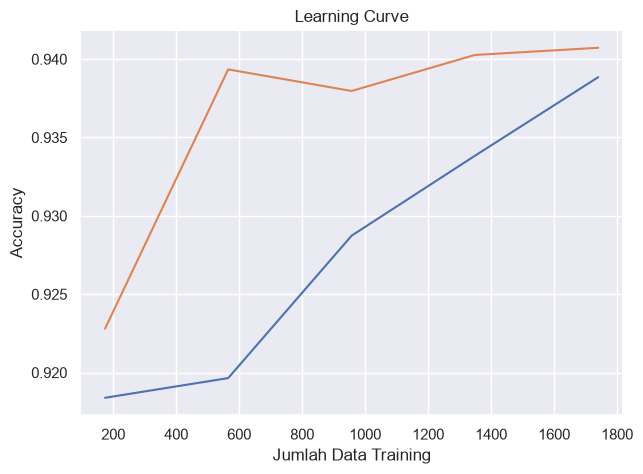

In [242]:
train_sizes, train_scores, val_scores = learning_curve(
    nb,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))

plt.plot(
    train_sizes,
    train_mean,
    label="Training Score"
)

plt.plot(
    train_sizes,
    val_mean,
    label="Validation Score"
)

plt.xlabel("Jumlah Data Training")
plt.ylabel("Accuracy")

plt.title("Learning Curve")
plt.show()
plt.legend()

save_plot("learning_curve.png")

Berdasarkan grafik *Learning Curve*, algoritma `Naive Bayes` menunjukkan performa yang stabil selama proses pembelajaran. Nilai `Training Accuracy` dan `Validation Accuracy` mengalami peningkatan seiring bertambahnya jumlah data training.

Pada awal proses pembelajaran terlihat bahwa nilai `Validation Accuracy` lebih tinggi dibandingkan `Training Accuracy`. Kondisi ini masih dapat terjadi pada proses *cross validation*, terutama ketika distribusi data validasi lebih mudah dipelajari dibandingkan sebagian data training pada ukuran sampel yang kecil.

Seiring bertambahnya jumlah data training, kedua kurva semakin mendekati satu sama lain dan menunjukkan pola yang relatif stabil. Pada akhir proses pembelajaran, nilai `Training Accuracy` mencapai sekitar `93,9%`, sedangkan nilai `Validation Accuracy` mencapai sekitar `94,1%`.

Selisih kedua kurva sangat kecil dengan nilai `Gap ≈ -0,002`, yang menunjukkan bahwa model memiliki kemampuan generalisasi yang baik terhadap data yang belum pernah dilihat sebelumnya. Tidak terdapat indikasi `overfitting` karena performa pada data validasi tidak mengalami penurunan ketika jumlah data bertambah.

Selain itu, nilai `Validation Accuracy` yang konsisten berada di atas `90%` menunjukkan bahwa model mampu mengenali pola klasifikasi jaringan dengan baik. Oleh karena itu, model `Naive Bayes` dapat dikategorikan sebagai `GOOD FIT` karena memiliki performa validasi yang tinggi dan gap yang sangat kecil antara data training dan data validation.

Meskipun demikian, jika dibandingkan dengan algoritma `Random Forest`, performa `Naive Bayes` masih sedikit lebih rendah. Hal ini menunjukkan bahwa `Random Forest` lebih mampu menangkap hubungan kompleks antar parameter jaringan dibandingkan asumsi independensi yang digunakan oleh `Naive Bayes`.


### Feature Importances


In [243]:
importance = rf.feature_importances_

fi_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

fi_df

,Feature,Importance
2,packet_loss,0.823218
1,latency,0.085771
3,uptime,0.069041
0,bandwidth,0.021970


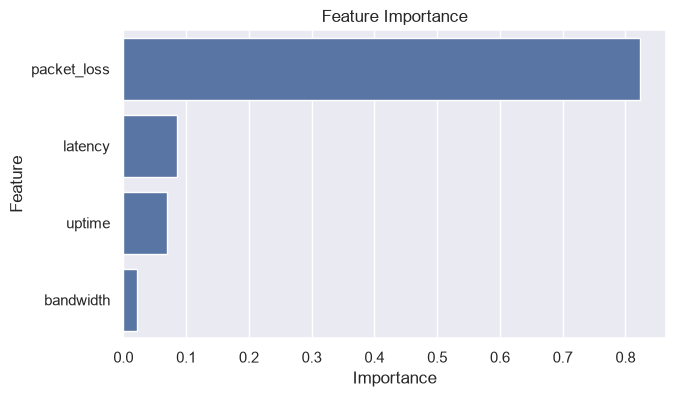

In [244]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=fi_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()
save_plot("feature_importance.png")

Berdasarkan hasil analisis `Feature Importance`, parameter `packet_loss` memiliki kontribusi terbesar dalam proses klasifikasi gangguan jaringan dengan nilai importance sekitar `0.82`. Nilai tersebut jauh lebih tinggi dibandingkan fitur lainnya, sehingga menunjukkan bahwa `packet_loss` merupakan faktor utama yang digunakan model `Random Forest` dalam membedakan kondisi jaringan `normal` dan `gangguan`.

Parameter `latency` menempati urutan kedua dengan nilai importance sekitar `0.08`. Hal ini menunjukkan bahwa keterlambatan transmisi data masih memiliki pengaruh terhadap keputusan model, meskipun kontribusinya tidak sebesar `packet_loss`.

Selanjutnya, parameter `uptime` memiliki nilai importance sekitar `0.07`. Kontribusi yang relatif kecil ini menunjukkan bahwa variasi nilai `uptime` pada dataset tidak terlalu kuat dalam membedakan kondisi jaringan. Hasil ini juga sejalan dengan analisis sebelumnya yang menunjukkan bahwa distribusi `uptime` cenderung kurang bervariasi dibandingkan fitur lainnya.

Sementara itu, parameter `bandwidth` memiliki nilai importance paling rendah yaitu sekitar `0.02`. Hal ini mengindikasikan bahwa perubahan nilai `bandwidth` pada dataset penelitian tidak memberikan pengaruh yang signifikan terhadap proses klasifikasi yang dilakukan oleh model.

Secara keseluruhan, hasil `Feature Importance` menunjukkan bahwa model `Random Forest` lebih banyak mengandalkan parameter `packet_loss` sebagai indikator utama dalam mendeteksi gangguan jaringan. Dengan demikian dapat disimpulkan bahwa peningkatan nilai `packet_loss` merupakan faktor yang paling berpengaruh terhadap kemungkinan terjadinya gangguan jaringan pada dataset penelitian ini.

Feature importance memperlihatkan kontribusi masing-masing parameter jaringan terhadap proses klasifikasi.

Melalui analisis ini dapat diketahui parameter mana yang paling berpengaruh dalam membedakan kondisi normal dan gangguan pada jaringan.

# Deployment

Tahap Deployment dilakukan dengan menyimpan model Machine Learning, scaler, dan label encoder ke dalam format PKL menggunakan Joblib. Model yang telah disimpan kemudian diintegrasikan ke dalam aplikasi berbasis Flask sehingga dapat digunakan untuk melakukan prediksi kondisi jaringan secara real-time melalui antarmuka web.

Implementasi deployment memungkinkan hasil penelitian digunakan secara langsung oleh tim teknisi jaringan tanpa perlu menjalankan kembali proses pelatihan model.

### Menyimpan Model Hasil Training

In [245]:
# Save Model  Hasil Training Menggunakan Joblib 

joblib.dump(
    rf,
    os.path.join(MODELS_DIR, "rf_model.pkl")
)

joblib.dump(
    nb,
    os.path.join(MODELS_DIR, "nb_model.pkl")
)

joblib.dump(
    scaler,
    os.path.join(MODELS_DIR, "scaler.pkl")
)

joblib.dump(
    le,
    os.path.join(MODELS_DIR, "label_encoder.pkl")
)

['c:\\Users\\lenovo\\OneDrive\\Desktop\\Git Uploads\\Klasifikasi-Gangguan-Jaringan-Kantor-Kominfo-Berdasarkan-Parameter\\Hybrid Model\\models\\label_encoder.pkl']